[MAP] ep= 9500 | total=4.9690e-01 | data=4.6053e-01 | phys=3.6367e-02 | prior=3.5587e-01
Training rPINN sample 1/5
Training rPINN sample 2/5
Training rPINN sample 3/5
Training rPINN sample 4/5
Training rPINN sample 5/5
================ Summary ================
MAP best loss                : 4.963304e-01
Mean rPINN best loss         : 1.454808e+00
State posterior RMSE         : 2.313390e-02
G posterior mean rel L2 error: 1.448364e-01
95% band coverage (~mean±2σ) : 100.00%


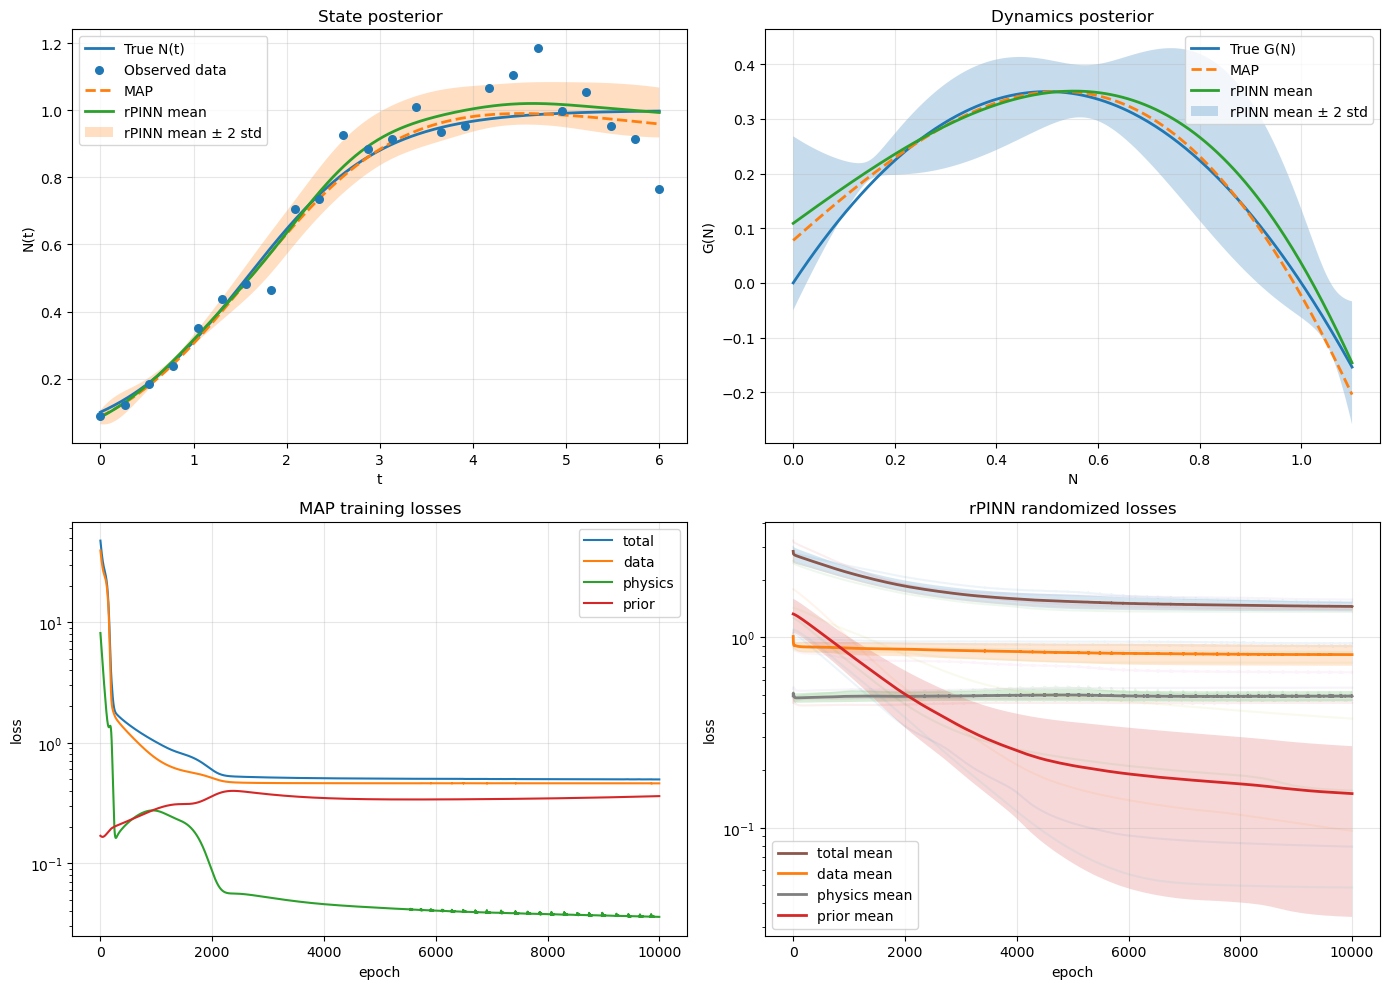

In [18]:
import copy
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# ============================================================
# Reproducibility / device
# ============================================================
torch.manual_seed(0)
np.random.seed(0)
device = torch.device("cpu")


# ============================================================
# 1. Ground-truth system: logistic growth dN/dt = r N (1 - N)
# ============================================================
r_true = 1.4
N0 = 0.1
numpts = 4 * (24 // 4)

t_obs = torch.linspace(0.0, 6.0, numpts, device=device).view(-1, 1)

def G_true(N):
    return r_true * N * (1.0 - N)


# ============================================================
# 2. Generate synthetic observed data
#    Noise law is heteroscedastic: sigma_true(N) = 0.1 N
# ============================================================
def rk4_step(f, y, t, dt):
    k1 = f(t, y)
    k2 = f(t + 0.5 * dt, y + 0.5 * dt * k1)
    k3 = f(t + 0.5 * dt, y + 0.5 * dt * k2)
    k4 = f(t + dt, y + dt * k3)
    return y + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)

def odeint_rk4(f, y0, t):
    ys = [y0]
    y = y0
    for i in range(len(t) - 1):
        ti = t[i]
        dt = t[i + 1] - t[i]
        y = rk4_step(f, y, ti, dt)
        ys.append(y)
    return torch.stack(ys, dim=0)

with torch.no_grad():
    y0_true = torch.tensor([[N0]], dtype=torch.float32, device=device)
    y_true = odeint_rk4(lambda t, y: G_true(y), y0_true, t_obs.squeeze()).squeeze(1)

torch.manual_seed(0)
y_data = y_true + 0.1 * torch.randn_like(y_true) * y_true


# ============================================================
# 3. Networks
# ============================================================
class SolutionNet(nn.Module):
    def __init__(self, hidden_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, t):
        return self.net(t)


class DynamicsNet(nn.Module):
    def __init__(self, hidden_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, N):
        return self.net(N)


# ============================================================
# 4. Helpers
# ============================================================
def make_sigma_data_from_obs(y_obs, floor=0.02):
    """
    Known heteroscedastic observation model.
    Since the true law is sigma(N)=0.1*N and in the experimental setup
    you said we may use the true sigma model added to the data, we build
    a fixed observation-dependent sigma from the observed data.
    """
    return 0.1 * torch.clamp(y_obs.abs(), min=floor)

def flatten_param_count(model):
    return sum(p.numel() for p in model.parameters())

def l2_prior_loss(model, sigma_prior):
    """
    Standard Gaussian prior in normalized coordinates:
    0.5 * mean((theta / sigma_prior)^2)
    """
    loss = 0.0
    nblocks = 0
    for p in model.parameters():
        loss = loss + 0.5 * torch.mean((p / sigma_prior) ** 2)
        nblocks += 1
    return loss / nblocks

def randomized_prior_loss(model, noise_list, sigma_prior):
    """
    Randomized prior term:
    0.5 * mean((theta / sigma_prior - eta)^2)
    where eta ~ N(0, I)
    """
    loss = 0.0
    nblocks = 0
    for p, eta in zip(model.parameters(), noise_list):
        loss = loss + 0.5 * torch.mean((p / sigma_prior - eta) ** 2)
        nblocks += 1
    return loss / nblocks

def grad_wrt_t(y, t):
    return torch.autograd.grad(
        outputs=y,
        inputs=t,
        grad_outputs=torch.ones_like(y),
        create_graph=True,
        retain_graph=True,
    )[0]


# ============================================================
# 5. Bayesian/MAP and randomized rPINN losses
# ============================================================
# Collocation points for physics residual
t_phys = torch.linspace(0.0, 6.0, 300, device=device).view(-1, 1)

# Known observation uncertainty model from data
sigma_data = make_sigma_data_from_obs(y_data)

# Hyperparameters
sigma_phys = 0.1     # physics residual scale
sigma_prior = 1.0     # weight prior std

def compute_map_losses(sol_net, dyn_net, t_obs, y_data, sigma_data, t_phys,
                       sigma_phys=0.05, sigma_prior=1.0):
    """
    Deterministic PINN/MAP objective:
      data NLL surrogate + physics residual + Gaussian parameter priors
    No initial-condition term is used.
    """
    # ----- data term -----
    N_obs = sol_net(t_obs)
    data_res = (N_obs - y_data) / sigma_data
    data_loss = 0.5 * torch.mean(data_res ** 2)

    # ----- physics term -----
    t_phys_req = t_phys.clone().detach().requires_grad_(True)
    N_phys = sol_net(t_phys_req)
    dN_dt = grad_wrt_t(N_phys, t_phys_req)
    G_phys = dyn_net(N_phys)
    phys_res = (dN_dt - G_phys) / sigma_phys
    physics_loss = 0.5 * torch.mean(phys_res ** 2)

    # ----- Gaussian priors on NN weights -----
    prior_sol = l2_prior_loss(sol_net, sigma_prior)
    prior_dyn = l2_prior_loss(dyn_net, sigma_prior)
    prior_loss = prior_sol + prior_dyn

    total = data_loss + physics_loss #+ prior_loss
    return {
        "total": total,
        "data": data_loss,
        "physics": physics_loss,
        "prior": prior_loss,
    }

def sample_rpinn_noises(sol_net, dyn_net, y_shape, phys_shape, device):
    """
    In normalized coordinates, all randomized targets are standard normal.
    """
    noise = {
        "data": torch.randn(y_shape, device=device),
        "physics": torch.randn(phys_shape, device=device),
        "sol_prior": [torch.randn_like(p) for p in sol_net.parameters()],
        "dyn_prior": [torch.randn_like(p) for p in dyn_net.parameters()],
    }
    return noise

def compute_randomized_losses(sol_net, dyn_net, t_obs, y_data, sigma_data, t_phys, noise,
                              sigma_phys=0.05, sigma_prior=1.0):
    """
    rPINN randomized objective:
      0.5 * || standardized_residual - random_noise ||^2
    for data, physics, and prior terms.
    """
    # ----- randomized data term -----
    N_obs = sol_net(t_obs)
    data_res = (N_obs - y_data) / sigma_data
    data_loss = 0.5 * torch.mean((data_res - noise["data"]) ** 2)

    # ----- randomized physics term -----
    t_phys_req = t_phys.clone().detach().requires_grad_(True)
    N_phys = sol_net(t_phys_req)
    dN_dt = grad_wrt_t(N_phys, t_phys_req)
    G_phys = dyn_net(N_phys)
    phys_res = (dN_dt - G_phys) / sigma_phys
    physics_loss = 0.5 * torch.mean((phys_res - noise["physics"]) ** 2)

    # ----- randomized priors -----
    prior_sol = randomized_prior_loss(sol_net, noise["sol_prior"], sigma_prior)
    prior_dyn = randomized_prior_loss(dyn_net, noise["dyn_prior"], sigma_prior)
    prior_loss = prior_sol + prior_dyn

    total = data_loss + physics_loss + prior_loss
    return {
        "total": total,
        "data": data_loss,
        "physics": physics_loss,
        "prior": prior_loss,
    }


# ============================================================
# 6. Training utilities
# ============================================================
def train_map_model(sol_net, dyn_net,
                    t_obs, y_data, sigma_data, t_phys,
                    lr=1e-3, epochs=4000,
                    sigma_phys=0.05, sigma_prior=1.0,
                    verbose_every=500):
    params = list(sol_net.parameters()) + list(dyn_net.parameters())
    opt = torch.optim.Adam(params, lr=lr)

    history = {"total": [], "data": [], "physics": [], "prior": []}
    best_loss = float("inf")
    best_state = None

    for ep in range(epochs):
        opt.zero_grad()
        losses = compute_map_losses(
            sol_net, dyn_net, t_obs, y_data, sigma_data, t_phys,
            sigma_phys=sigma_phys, sigma_prior=sigma_prior
        )
        losses["total"].backward()
        opt.step()

        for k in history:
            history[k].append(losses[k].item())

        if losses["total"].item() < best_loss:
            best_loss = losses["total"].item()
            best_state = {
                "sol": copy.deepcopy(sol_net.state_dict()),
                "dyn": copy.deepcopy(dyn_net.state_dict()),
            }

        if verbose_every is not None and ep % verbose_every == 0:
            print(
                f"[MAP] ep={ep:5d} | "
                f"total={losses['total'].item():.4e} | "
                f"data={losses['data'].item():.4e} | "
                f"phys={losses['physics'].item():.4e} | "
                f"prior={losses['prior'].item():.4e}",
                end="\r"
            )

    sol_net.load_state_dict(best_state["sol"])
    dyn_net.load_state_dict(best_state["dyn"])
    return history, best_loss

def train_rpinn_sample(base_sol_state, base_dyn_state,
                       t_obs, y_data, sigma_data, t_phys,
                       hidden_dim=64, lr=1e-3, epochs=2000,
                       sigma_phys=0.05, sigma_prior=1.0,
                       warmstart_noise=1e-2, verbose=False):
    """
    Train one randomized sample, initialized from MAP weights + tiny perturbation.
    """
    sol_net = SolutionNet(hidden_dim=hidden_dim).to(device)
    dyn_net = DynamicsNet(hidden_dim=hidden_dim).to(device)
    sol_net.load_state_dict(copy.deepcopy(base_sol_state))
    dyn_net.load_state_dict(copy.deepcopy(base_dyn_state))

    with torch.no_grad():
        for p in sol_net.parameters():
            p.add_(warmstart_noise * torch.randn_like(p))
        for p in dyn_net.parameters():
            p.add_(warmstart_noise * torch.randn_like(p))

    noise = sample_rpinn_noises(
        sol_net, dyn_net,
        y_shape=y_data.shape,
        phys_shape=(t_phys.shape[0], 1),
        device=device
    )

    params = list(sol_net.parameters()) + list(dyn_net.parameters())
    opt = torch.optim.Adam(params, lr=lr)

    history = {"total": [], "data": [], "physics": [], "prior": []}
    best_loss = float("inf")
    best_state = None

    for ep in range(epochs):
        opt.zero_grad()
        losses = compute_randomized_losses(
            sol_net, dyn_net, t_obs, y_data, sigma_data, t_phys, noise,
            sigma_phys=sigma_phys, sigma_prior=sigma_prior
        )
        losses["total"].backward()
        opt.step()

        for k in history:
            history[k].append(losses[k].item())

        if losses["total"].item() < best_loss:
            best_loss = losses["total"].item()
            best_state = {
                "sol": copy.deepcopy(sol_net.state_dict()),
                "dyn": copy.deepcopy(dyn_net.state_dict()),
            }

        if verbose and ep % 500 == 0:
            print(
                f"[rPINN] ep={ep:5d} | "
                f"total={losses['total'].item():.4e} | "
                f"data={losses['data'].item():.4e} | "
                f"phys={losses['physics'].item():.4e} | "
                f"prior={losses['prior'].item():.4e}",
                 end="\r"
            )

    sol_net.load_state_dict(best_state["sol"])
    dyn_net.load_state_dict(best_state["dyn"])

    return sol_net, dyn_net, history, best_loss


# ============================================================
# 7. MAP pretraining
# ============================================================
hidden_dim = 4

map_sol = SolutionNet(hidden_dim=hidden_dim).to(device)
map_dyn = DynamicsNet(hidden_dim=hidden_dim).to(device)

map_history, map_best = train_map_model(
    map_sol, map_dyn,
    t_obs, y_data, sigma_data, t_phys,
    lr=1e-3,
    epochs=10000,
    sigma_phys=sigma_phys,
    sigma_prior=sigma_prior,
    verbose_every=500
)

base_sol_state = copy.deepcopy(map_sol.state_dict())
base_dyn_state = copy.deepcopy(map_dyn.state_dict())


# ============================================================
# 8. rPINN ensemble
# ============================================================
n_samples = 5   # increase if you want smoother posterior estimates
sample_histories = []
sol_samples = []
dyn_samples = []
sample_best_losses = []

for s in range(n_samples):
    print(f"\nTraining rPINN sample {s+1}/{n_samples}", end="\r")
    sol_s, dyn_s, hist_s, best_s = train_rpinn_sample(
        base_sol_state, base_dyn_state,
        t_obs, y_data, sigma_data, t_phys,
        hidden_dim=hidden_dim,
        lr=1e-3,
        epochs=10000,
        sigma_phys=sigma_phys,
        sigma_prior=sigma_prior,
        warmstart_noise=0,
        verbose=False
    )
    sol_samples.append(sol_s)
    dyn_samples.append(dyn_s)
    sample_histories.append(hist_s)
    sample_best_losses.append(best_s)


# ============================================================
# 9. Posterior predictions
# ============================================================
t_plot = torch.linspace(0.0, 6.0, 400, device=device).view(-1, 1)

with torch.no_grad():
    y_true_dense = odeint_rk4(
        lambda t, y: G_true(y),
        torch.tensor([[N0]], dtype=torch.float32, device=device),
        t_plot.squeeze()
    ).squeeze(1)

    # State posterior
    N_ensemble = []
    for sol_s in sol_samples:
        N_ensemble.append(sol_s(t_plot).squeeze(-1))
    N_ensemble = torch.stack(N_ensemble, dim=0)   # [S, T]

    N_mean = N_ensemble.mean(dim=0)
    N_std = N_ensemble.std(dim=0)

    # Dynamics posterior
    N_grid = torch.linspace(
        0.0,
        max(1.1, float(torch.max(y_true_dense).cpu()) + 0.05),
        300,
        device=device
    ).view(-1, 1)

    G_ensemble = []
    for dyn_s in dyn_samples:
        G_ensemble.append(dyn_s(N_grid).squeeze(-1))
    G_ensemble = torch.stack(G_ensemble, dim=0)   # [S, M]

    G_mean = G_ensemble.mean(dim=0)
    G_std = G_ensemble.std(dim=0)
    G_exact = G_true(N_grid).squeeze(-1)

    # MAP prediction for reference
    N_map = map_sol(t_plot).squeeze(-1)
    G_map = map_dyn(N_grid).squeeze(-1)


# ============================================================
# 10. Aggregate sample loss histories
# ============================================================
def aggregate_histories(sample_histories, key):
    arr = np.array([h[key] for h in sample_histories])  # [S, epochs]
    return arr.mean(axis=0), arr.std(axis=0), arr

rpinn_loss_stats = {}
for k in ["total", "data", "physics", "prior"]:
    rpinn_loss_stats[k] = aggregate_histories(sample_histories, k)

map_epochs = np.arange(len(map_history["total"]))
rpinn_epochs = np.arange(len(sample_histories[0]["total"]))


# ============================================================
# 11. Metrics
# ============================================================
with torch.no_grad():
    # Coverage of true state by posterior mean ± 2 std on dense grid
    lower = N_mean - 2.0 * N_std
    upper = N_mean + 2.0 * N_std
    coverage = ((y_true_dense.squeeze(-1) >= lower) & (y_true_dense.squeeze(-1) <= upper)).float().mean().item()

    # RMSE of posterior mean
    rmse_state = torch.sqrt(torch.mean((N_mean - y_true_dense.squeeze(-1)) ** 2)).item()

    # Relative L2 error in posterior mean G
    rel_l2_G = (torch.norm(G_mean - G_exact) / torch.norm(G_exact)).item()

print("\n================ Summary ================")
print(f"MAP best loss                : {map_best:.6e}")
print(f"Mean rPINN best loss         : {np.mean(sample_best_losses):.6e}")
print(f"State posterior RMSE         : {rmse_state:.6e}")
print(f"G posterior mean rel L2 error: {rel_l2_G:.6e}")
print(f"95% band coverage (~mean±2σ) : {coverage*100:.2f}%")
print("=========================================")


# ============================================================
# 12. Plots
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ------------------------------------------------------------
# (a) State posterior N(t)
# ------------------------------------------------------------
ax = axes[0, 0]
ax.plot(t_plot.cpu(), y_true_dense.cpu(), lw=2, label="True N(t)")
ax.scatter(t_obs.cpu(), y_data.cpu(), s=30, zorder=3, label="Observed data")
ax.plot(t_plot.cpu(), N_map.cpu(), "--", lw=2, label="MAP")
ax.plot(t_plot.cpu(), N_mean.cpu(), lw=2, label="rPINN mean")
ax.fill_between(
    t_plot.squeeze(-1).cpu().numpy(),
    (N_mean - 2*N_std).cpu().numpy(),
    (N_mean + 2*N_std).cpu().numpy(),
    alpha=0.25,
    label="rPINN mean ± 2 std"
)
ax.set_title("State posterior")
ax.set_xlabel("t")
ax.set_ylabel("N(t)")
ax.grid(True, alpha=0.3)
ax.legend()

# ------------------------------------------------------------
# (b) Dynamics posterior G(N)
# ------------------------------------------------------------
ax = axes[0, 1]
ax.plot(N_grid.cpu(), G_exact.cpu(), lw=2, label="True G(N)")
ax.plot(N_grid.cpu(), G_map.cpu(), "--", lw=2, label="MAP")
ax.plot(N_grid.cpu(), G_mean.cpu(), lw=2, label="rPINN mean")
ax.fill_between(
    N_grid.squeeze(-1).cpu().numpy(),
    (G_mean - 2*G_std).cpu().numpy(),
    (G_mean + 2*G_std).cpu().numpy(),
    alpha=0.25,
    label="rPINN mean ± 2 std"
)
ax.set_title("Dynamics posterior")
ax.set_xlabel("N")
ax.set_ylabel("G(N)")
ax.grid(True, alpha=0.3)
ax.legend()

# ------------------------------------------------------------
# (c) MAP losses
# ------------------------------------------------------------
ax = axes[1, 0]
for k in ["total", "data", "physics", "prior"]:
    ax.plot(map_epochs, map_history[k], label=k)
ax.set_yscale("log")
ax.set_title("MAP training losses")
ax.set_xlabel("epoch")
ax.set_ylabel("loss")
ax.grid(True, alpha=0.3)
ax.legend()

# ------------------------------------------------------------
# (d) rPINN losses: mean ± std across randomized runs
# ------------------------------------------------------------
ax = axes[1, 1]
for k in ["total", "data", "physics", "prior"]:
    mean_k, std_k, raw_k = rpinn_loss_stats[k]

    # faint individual runs
    for i in range(raw_k.shape[0]):
        ax.plot(rpinn_epochs, raw_k[i], alpha=0.08)

    # ensemble mean ± std
    ax.plot(rpinn_epochs, mean_k, lw=2, label=f"{k} mean")
    ax.fill_between(
        rpinn_epochs,
        np.maximum(mean_k - std_k, 1e-12),
        mean_k + std_k,
        alpha=0.18
    )

ax.set_yscale("log")
ax.set_title("rPINN randomized losses")
ax.set_xlabel("epoch")
ax.set_ylabel("loss")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()


[PINN] ep= 9500 | train=2.0693e-03 | val=8.1945e-03
[PINN] ep= 9500 | train=2.9142e-03 | val=4.4048e-03
[PINN] ep= 9500 | train=2.6307e-03 | val=5.0130e-03
[PINN] ep= 9500 | train=2.3998e-03 | val=5.3293e-03
================ Ensemble over splits ================
Number of splits              : 4
Mean best validation loss     : 5.551063e-03
Std  best validation loss     : 1.507039e-03
Mean best epoch               : 7299.50
State ensemble RMSE           : 1.513436e-02
G ensemble mean rel L2 error  : 1.463660e-01
95% band coverage (~mean±2σ)  : 83.50%


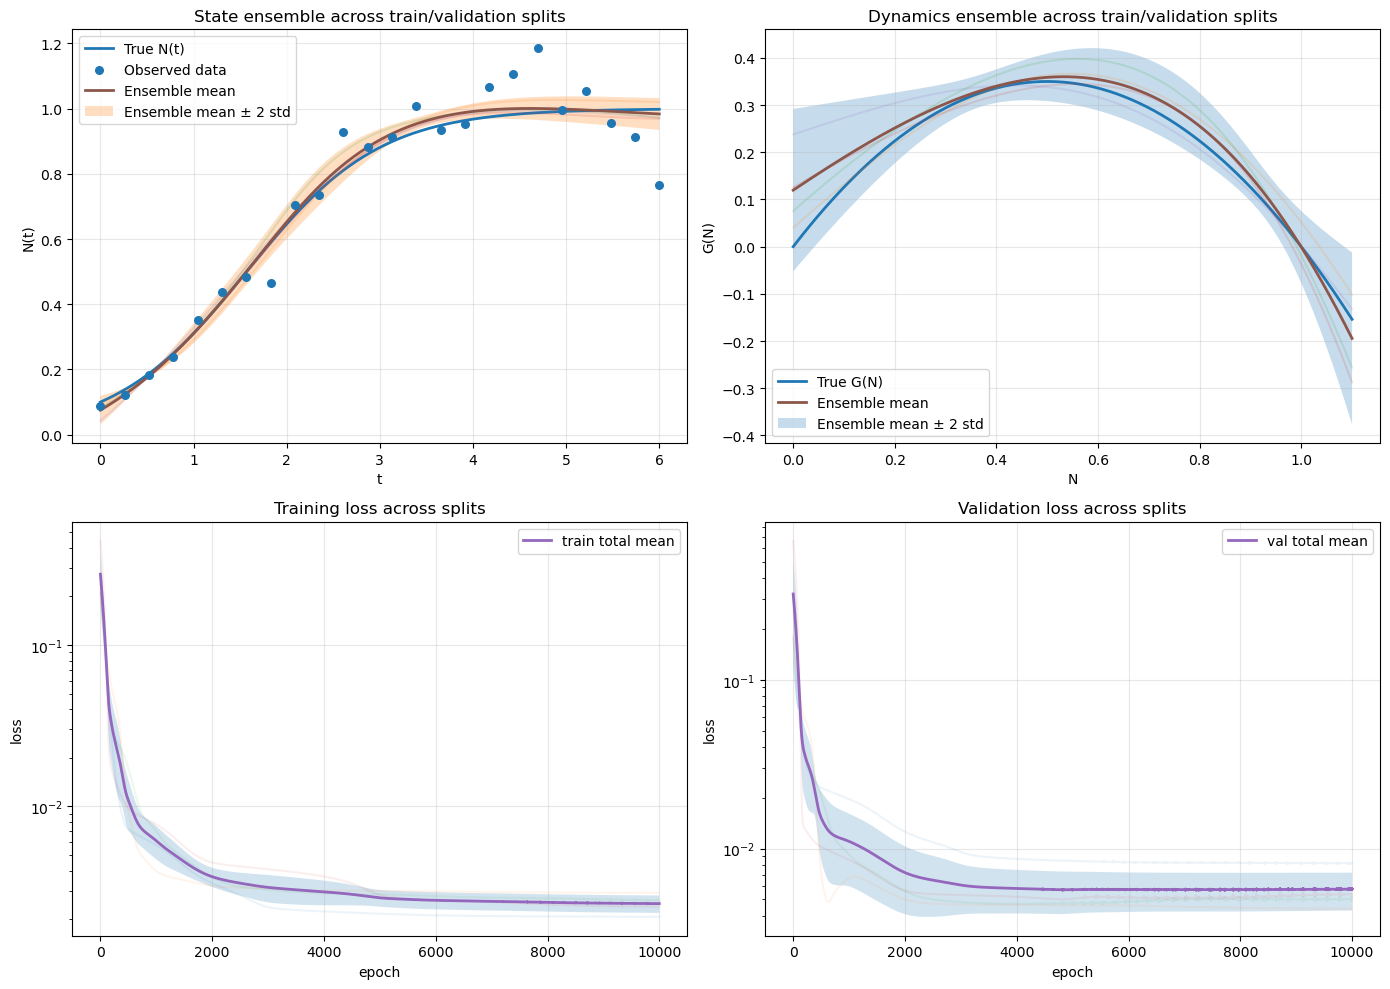

In [31]:
import copy
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# ============================================================
# Reproducibility / device
# ============================================================
torch.manual_seed(0)
np.random.seed(0)
device = torch.device("cpu")


# ============================================================
# 1. Ground-truth system: logistic growth dN/dt = r N (1 - N)
# ============================================================
r_true = 1.4
N0 = 0.1
numpts = 4 * (24 // 4)

t_obs = torch.linspace(0.0, 6.0, numpts, device=device).view(-1, 1)

def G_true(N):
    return r_true * N * (1.0 - N)


# ============================================================
# 2. Generate synthetic observed data
# ============================================================
def rk4_step(f, y, t, dt):
    k1 = f(t, y)
    k2 = f(t + 0.5 * dt, y + 0.5 * dt * k1)
    k3 = f(t + 0.5 * dt, y + 0.5 * dt * k2)
    k4 = f(t + dt, y + dt * k3)
    return y + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)

def odeint_rk4(f, y0, t):
    ys = [y0]
    y = y0
    for i in range(len(t) - 1):
        ti = t[i]
        dt = t[i + 1] - t[i]
        y = rk4_step(f, y, ti, dt)
        ys.append(y)
    return torch.stack(ys, dim=0)

with torch.no_grad():
    y0_true = torch.tensor([[N0]], dtype=torch.float32, device=device)
    y_true = odeint_rk4(lambda t, y: G_true(y), y0_true, t_obs.squeeze()).squeeze(1)

torch.manual_seed(0)
y_data = y_true + 0.1 * torch.randn_like(y_true) * y_true


# ============================================================
# 3. Networks
# ============================================================
class SolutionNet(nn.Module):
    def __init__(self, hidden_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, t):
        return self.net(t)


class DynamicsNet(nn.Module):
    def __init__(self, hidden_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, N):
        return self.net(N)


# ============================================================
# 4. Helpers
# ============================================================
def l2_prior_loss(model, sigma_prior=1.0):
    loss = 0.0
    nblocks = 0
    for p in model.parameters():
        loss = loss + 0.5 * torch.mean((p / sigma_prior) ** 2)
        nblocks += 1
    return loss / max(nblocks, 1)

def grad_wrt_t(y, t):
    return torch.autograd.grad(
        outputs=y,
        inputs=t,
        grad_outputs=torch.ones_like(y),
        create_graph=True,
        retain_graph=True,
    )[0]


# ============================================================
# 5. Standard deterministic PINN losses (plain L2)
# ============================================================
t_phys = torch.linspace(0.0, 6.0, 300, device=device).view(-1, 1)

def compute_pinn_losses(sol_net, dyn_net,
                        t_data, y_data,
                        t_phys,
                        lambda_phys=1.0,
                        lambda_prior=0.0):
    # ----- data loss (L2) -----
    N_obs = sol_net(t_data)
    data_loss = 0.5 * torch.mean((N_obs - y_data) ** 2)

    # ----- physics loss (L2) -----
    t_phys_req = t_phys.clone().detach().requires_grad_(True)
    N_phys = sol_net(t_phys_req)
    dN_dt = grad_wrt_t(N_phys, t_phys_req)
    G_phys = dyn_net(N_phys)
    physics_loss = 0.5 * torch.mean((dN_dt - G_phys) ** 2)

    # ----- optional prior / weight decay term -----
    prior_sol = l2_prior_loss(sol_net, sigma_prior=1.0)
    prior_dyn = l2_prior_loss(dyn_net, sigma_prior=1.0)
    prior_loss = prior_sol + prior_dyn

    total = data_loss + lambda_phys * physics_loss + lambda_prior * prior_loss

    return {
        "total": total,
        "data": data_loss,
        "physics": physics_loss,
        "prior": prior_loss,
    }

def evaluate_on_split(sol_net, dyn_net,
                      t_eval, y_eval,
                      t_phys,
                      lambda_phys=1.0,
                      lambda_prior=0.0):
    with torch.enable_grad():
        losses = compute_pinn_losses(
            sol_net, dyn_net,
            t_eval, y_eval,
            t_phys,
            lambda_phys=lambda_phys,
            lambda_prior=lambda_prior,
        )
    return {k: float(v.detach().cpu()) for k, v in losses.items()}


# ============================================================
# 6. Training utility
# ============================================================
def train_pinn_model(sol_net, dyn_net,
                     t_train, y_train,
                     t_val, y_val,
                     t_phys,
                     lr=1e-3, epochs=4000,
                     lambda_phys=1.0,
                     lambda_prior=0.0,
                     verbose_every=500):
    params = list(sol_net.parameters()) + list(dyn_net.parameters())
    opt = torch.optim.Adam(params, lr=lr)

    history = {
        "train_total": [], "train_data": [], "train_physics": [], "train_prior": [],
        "val_total": [], "val_data": [], "val_physics": [], "val_prior": [],
    }

    best_val = float("inf")
    best_state = None

    for ep in range(epochs):
        opt.zero_grad()

        train_losses = compute_pinn_losses(
            sol_net, dyn_net,
            t_train, y_train,
            t_phys,
            lambda_phys=lambda_phys,
            lambda_prior=lambda_prior,
        )
        train_losses["total"].backward()
        opt.step()

        val_losses = evaluate_on_split(
            sol_net, dyn_net,
            t_val, y_val,
            t_phys,
            lambda_phys=lambda_phys,
            lambda_prior=lambda_prior,
        )

        history["train_total"].append(train_losses["total"].item())
        history["train_data"].append(train_losses["data"].item())
        history["train_physics"].append(train_losses["physics"].item())
        history["train_prior"].append(train_losses["prior"].item())

        history["val_total"].append(val_losses["total"])
        history["val_data"].append(val_losses["data"])
        history["val_physics"].append(val_losses["physics"])
        history["val_prior"].append(val_losses["prior"])

        # best model for this split = minimum validation loss
        if val_losses["total"] < best_val:
            best_val = val_losses["total"]
            best_state = {
                "sol": copy.deepcopy(sol_net.state_dict()),
                "dyn": copy.deepcopy(dyn_net.state_dict()),
                "epoch": ep,
            }

        if verbose_every is not None and ep % verbose_every == 0:
            print(
                f"[PINN] ep={ep:5d} | "
                f"train={train_losses['total'].item():.4e} | "
                f"val={val_losses['total']:.4e}",
                end="\r",
            )

    sol_net.load_state_dict(best_state["sol"])
    dyn_net.load_state_dict(best_state["dyn"])

    return history, best_val, best_state["epoch"]


# ============================================================
# 7. Train/validation split generator
#    Repeated random holdout splits
# ============================================================
def make_random_splits(n, n_splits=10, val_fraction=0.25, seed=0):
    rng = np.random.default_rng(seed)
    indices = np.arange(n)
    splits = []

    n_val = max(1, int(round(val_fraction * n)))

    for _ in range(n_splits):
        perm = rng.permutation(indices)
        val_idx = np.sort(perm[:n_val])
        train_idx = np.sort(perm[n_val:])
        splits.append((train_idx, val_idx))

    return splits


# ============================================================
# 8. Ensemble over train/validation splits
#    Each member is the best checkpoint from its split,
#    chosen by minimum validation loss.
# ============================================================
hidden_dim = 4
n_splits = 4
epochs = 10000
lambda_phys = 1.0
lambda_prior = 0.0

splits = make_random_splits(
    len(t_obs),
    n_splits=n_splits,
    val_fraction=0.2,
    seed=123
)

ensemble_solutions = []
ensemble_dynamics = []
ensemble_histories = []
split_metrics = []

for i, (train_idx, val_idx) in enumerate(splits):
    print(f"\nTraining split {i+1}/{n_splits}", end="\r")

    t_train = t_obs[train_idx]
    y_train = y_data[train_idx]

    t_val = t_obs[val_idx]
    y_val = y_data[val_idx]

    sol_net = SolutionNet(hidden_dim=hidden_dim).to(device)
    dyn_net = DynamicsNet(hidden_dim=hidden_dim).to(device)

    history, best_val, best_epoch = train_pinn_model(
        sol_net, dyn_net,
        t_train, y_train,
        t_val, y_val,
        t_phys,
        lr=1e-3,
        epochs=epochs,
        lambda_phys=lambda_phys,
        lambda_prior=lambda_prior,
        verbose_every=500,
    )

    # sol_net and dyn_net already contain the weights from the epoch
    # with minimum validation loss for this split
    ensemble_solutions.append(copy.deepcopy(sol_net))
    ensemble_dynamics.append(copy.deepcopy(dyn_net))
    ensemble_histories.append(history)
    split_metrics.append({
        "split": i,
        "best_val_total": best_val,
        "best_epoch": best_epoch,
        "n_train": len(train_idx),
        "n_val": len(val_idx),
        "train_idx": train_idx,
        "val_idx": val_idx,
    })


# ============================================================
# 9. Ensemble predictions
# ============================================================
t_plot = torch.linspace(0.0, 6.0, 400, device=device).view(-1, 1)

with torch.no_grad():
    y_true_dense = odeint_rk4(
        lambda t, y: G_true(y),
        torch.tensor([[N0]], dtype=torch.float32, device=device),
        t_plot.squeeze()
    ).squeeze(1)

    # State ensemble
    N_ensemble = []
    for sol_net in ensemble_solutions:
        N_ensemble.append(sol_net(t_plot).squeeze(-1))
    N_ensemble = torch.stack(N_ensemble, dim=0)   # [S, T]

    N_mean = N_ensemble.mean(dim=0)
    N_std = N_ensemble.std(dim=0)

    # Dynamics ensemble
    N_grid = torch.linspace(
        0.0,
        max(1.1, float(torch.max(y_true_dense).cpu()) + 0.05),
        300,
        device=device
    ).view(-1, 1)

    G_ensemble = []
    for dyn_net in ensemble_dynamics:
        G_ensemble.append(dyn_net(N_grid).squeeze(-1))
    G_ensemble = torch.stack(G_ensemble, dim=0)   # [S, M]

    G_mean = G_ensemble.mean(dim=0)
    G_std = G_ensemble.std(dim=0)
    G_exact = G_true(N_grid).squeeze(-1)


# ============================================================
# 10. Aggregate histories
# ============================================================
def aggregate_histories(histories, key):
    arr = np.array([h[key] for h in histories])  # [S, epochs]
    return arr.mean(axis=0), arr.std(axis=0), arr

history_stats = {}
for k in [
    "train_total", "train_data", "train_physics", "train_prior",
    "val_total", "val_data", "val_physics", "val_prior"
]:
    history_stats[k] = aggregate_histories(ensemble_histories, k)

epochs_axis = np.arange(len(ensemble_histories[0]["train_total"]))


# ============================================================
# 11. Metrics
# ============================================================
with torch.no_grad():
    lower = N_mean - 2.0 * N_std
    upper = N_mean + 2.0 * N_std
    coverage = (
        (y_true_dense.squeeze(-1) >= lower) &
        (y_true_dense.squeeze(-1) <= upper)
    ).float().mean().item()

    rmse_state = torch.sqrt(
        torch.mean((N_mean - y_true_dense.squeeze(-1)) ** 2)
    ).item()

    rel_l2_G = (torch.norm(G_mean - G_exact) / torch.norm(G_exact)).item()

print("\n================ Ensemble over splits ================")
print(f"Number of splits              : {n_splits}")
print(f"Mean best validation loss     : {np.mean([m['best_val_total'] for m in split_metrics]):.6e}")
print(f"Std  best validation loss     : {np.std([m['best_val_total'] for m in split_metrics]):.6e}")
print(f"Mean best epoch               : {np.mean([m['best_epoch'] for m in split_metrics]):.2f}")
print(f"State ensemble RMSE           : {rmse_state:.6e}")
print(f"G ensemble mean rel L2 error  : {rel_l2_G:.6e}")
print(f"95% band coverage (~mean±2σ)  : {coverage*100:.2f}%")
print("======================================================")


# ============================================================
# 12. Plots
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ------------------------------------------------------------
# (a) State ensemble N(t)
# ------------------------------------------------------------
ax = axes[0, 0]
ax.plot(t_plot.cpu(), y_true_dense.cpu(), lw=2, label="True N(t)")
ax.scatter(t_obs.cpu(), y_data.cpu(), s=30, zorder=3, label="Observed data")

for sol_net in ensemble_solutions:
    with torch.no_grad():
        pred_i = sol_net(t_plot).squeeze(-1)
    ax.plot(t_plot.cpu(), pred_i.cpu(), alpha=0.15)

ax.plot(t_plot.cpu(), N_mean.cpu(), lw=2, label="Ensemble mean")
ax.fill_between(
    t_plot.squeeze(-1).cpu().numpy(),
    (N_mean - 2 * N_std).cpu().numpy(),
    (N_mean + 2 * N_std).cpu().numpy(),
    alpha=0.25,
    label="Ensemble mean ± 2 std"
)
ax.set_title("State ensemble across train/validation splits")
ax.set_xlabel("t")
ax.set_ylabel("N(t)")
ax.grid(True, alpha=0.3)
ax.legend()

# ------------------------------------------------------------
# (b) Dynamics ensemble G(N)
# ------------------------------------------------------------
ax = axes[0, 1]
ax.plot(N_grid.cpu(), G_exact.cpu(), lw=2, label="True G(N)")

for dyn_net in ensemble_dynamics:
    with torch.no_grad():
        G_i = dyn_net(N_grid).squeeze(-1)
    ax.plot(N_grid.cpu(), G_i.cpu(), alpha=0.15)

ax.plot(N_grid.cpu(), G_mean.cpu(), lw=2, label="Ensemble mean")
ax.fill_between(
    N_grid.squeeze(-1).cpu().numpy(),
    (G_mean - 2 * G_std).cpu().numpy(),
    (G_mean + 2 * G_std).cpu().numpy(),
    alpha=0.25,
    label="Ensemble mean ± 2 std"
)
ax.set_title("Dynamics ensemble across train/validation splits")
ax.set_xlabel("N")
ax.set_ylabel("G(N)")
ax.grid(True, alpha=0.3)
ax.legend()

# ------------------------------------------------------------
# (c) Train losses
# ------------------------------------------------------------
ax = axes[1, 0]
for i in range(len(ensemble_histories)):
    ax.plot(epochs_axis, ensemble_histories[i]["train_total"], alpha=0.08)

mean_train, std_train, _ = history_stats["train_total"]
ax.plot(epochs_axis, mean_train, lw=2, label="train total mean")
ax.fill_between(
    epochs_axis,
    np.maximum(mean_train - std_train, 1e-12),
    mean_train + std_train,
    alpha=0.2
)
ax.set_yscale("log")
ax.set_title("Training loss across splits")
ax.set_xlabel("epoch")
ax.set_ylabel("loss")
ax.grid(True, alpha=0.3)
ax.legend()

# ------------------------------------------------------------
# (d) Validation losses
# ------------------------------------------------------------
ax = axes[1, 1]
for i in range(len(ensemble_histories)):
    ax.plot(epochs_axis, ensemble_histories[i]["val_total"], alpha=0.08)

mean_val, std_val, _ = history_stats["val_total"]
ax.plot(epochs_axis, mean_val, lw=2, label="val total mean")
ax.fill_between(
    epochs_axis,
    np.maximum(mean_val - std_val, 1e-12),
    mean_val + std_val,
    alpha=0.2
)
ax.set_yscale("log")
ax.set_title("Validation loss across splits")
ax.set_xlabel("epoch")
ax.set_ylabel("loss")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()


[PINN] ep= 9500 | train total=2.9585e-03 (data=2.8471e-03, phys=1.1145e-04, prior=4.0964e-01) | val total=1.0137e-02 (data=1.0025e-02, phys=1.1145e-04, prior=4.0966e-01)
Split 1/4 saved model | best epoch = 9948 | val total = 1.008723e-02

[PINN] ep= 9500 | train total=3.3748e-03 (data=3.1910e-03, phys=1.8379e-04, prior=5.3439e-01) | val total=9.2742e-03 (data=9.0905e-03, phys=1.8376e-04, prior=5.3440e-01)
Split 2/4 saved model | best epoch = 3475 | val total = 8.498367e-03

[PINN] ep= 9500 | train total=4.0940e-03 (data=3.9706e-03, phys=1.2332e-04, prior=6.4604e-01) | val total=4.8201e-03 (data=4.6963e-03, phys=1.2373e-04, prior=6.4607e-01)
Split 3/4 saved model | best epoch = 9723 | val total = 4.705650e-03

[PINN] ep= 9500 | train total=3.6248e-02 (data=3.6247e-02, phys=3.2417e-07, prior=3.2698e-01) | val total=1.5360e-02 (data=1.5360e-02, phys=3.2406e-07, prior=3.2699e-01)
Split 4/4 saved model | best epoch = 6829 | val total = 1.362260e-02

================ Ensemble over splits =

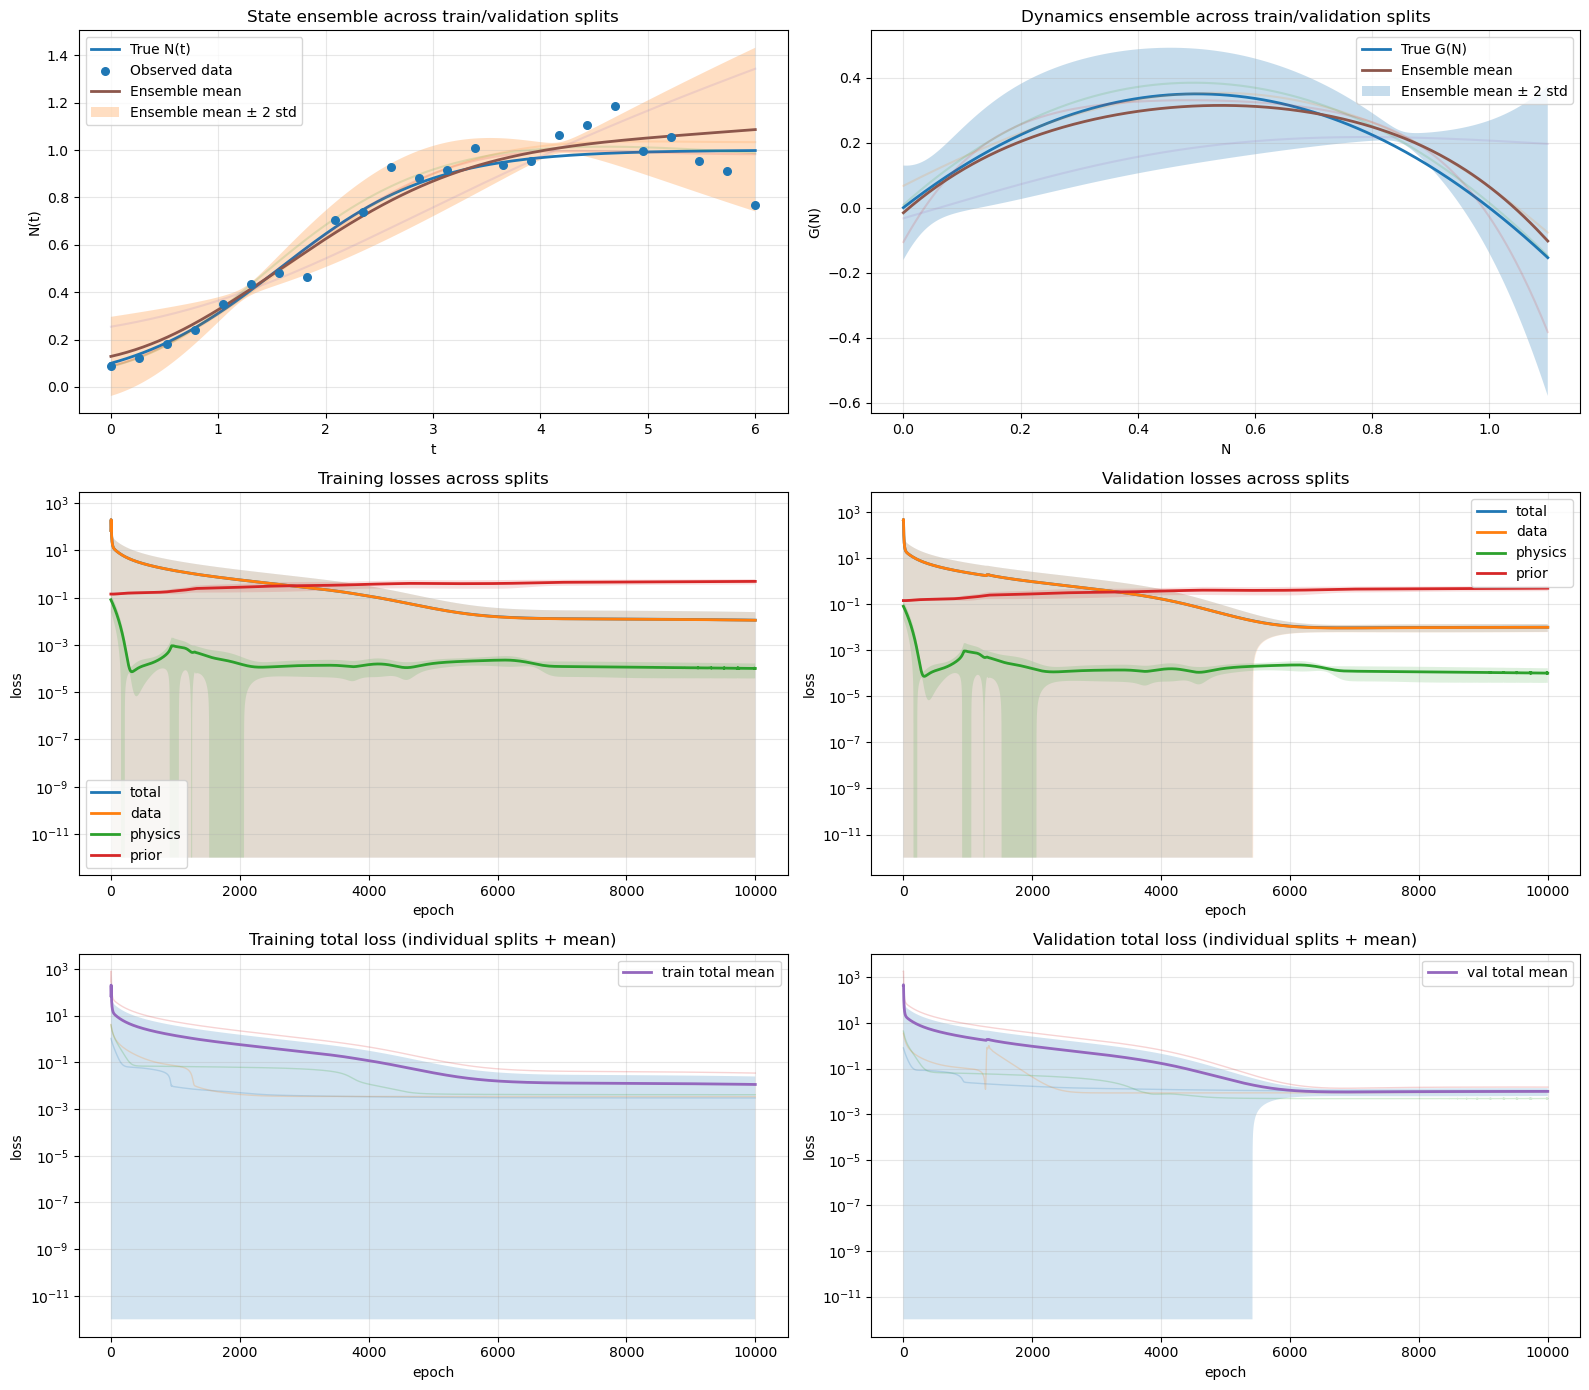

In [44]:
import copy
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# ============================================================
# Reproducibility / device
# ============================================================
torch.manual_seed(0)
np.random.seed(0)
device = torch.device("cpu")


# ============================================================
# 1. Ground-truth system: logistic growth dN/dt = r N (1 - N)
# ============================================================
r_true = 1.4
N0 = 0.1
numpts = 4 * (24 // 4)

t_obs = torch.linspace(0.0, 6.0, numpts, device=device).view(-1, 1)

def G_true(N):
    return r_true * N * (1.0 - N)


# ============================================================
# 2. Generate synthetic observed data
# ============================================================
def rk4_step(f, y, t, dt):
    k1 = f(t, y)
    k2 = f(t + 0.5 * dt, y + 0.5 * dt * k1)
    k3 = f(t + 0.5 * dt, y + 0.5 * dt * k2)
    k4 = f(t + dt, y + dt * k3)
    return y + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)

def odeint_rk4(f, y0, t):
    ys = [y0]
    y = y0
    for i in range(len(t) - 1):
        ti = t[i]
        dt = t[i + 1] - t[i]
        y = rk4_step(f, y, ti, dt)
        ys.append(y)
    return torch.stack(ys, dim=0)

with torch.no_grad():
    y0_true = torch.tensor([[N0]], dtype=torch.float32, device=device)
    y_true = odeint_rk4(lambda t, y: G_true(y), y0_true, t_obs.squeeze()).squeeze(1)

torch.manual_seed(0)
y_data = y_true + 0.1 * torch.randn_like(y_true) * y_true


# ============================================================
# 3. Networks
# ============================================================
class SolutionNet(nn.Module):
    def __init__(self, hidden_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, t):
        return self.net(t)


class DynamicsNet(nn.Module):
    def __init__(self, hidden_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, N):
        return self.net(N)


# ============================================================
# 4. Helpers
# ============================================================
def l2_prior_loss(model, sigma_prior=1.0):
    loss = 0.0
    nblocks = 0
    for p in model.parameters():
        loss = loss + 0.5 * torch.mean((p / sigma_prior) ** 2)
        nblocks += 1
    return loss / max(nblocks, 1)

def grad_wrt_t(y, t):
    return torch.autograd.grad(
        outputs=y,
        inputs=t,
        grad_outputs=torch.ones_like(y),
        create_graph=True,
        retain_graph=True,
    )[0]


# ============================================================
# 5. Standard deterministic PINN losses
# ============================================================
t_phys = torch.linspace(0.0, 6.0, 300, device=device).view(-1, 1)

def compute_pinn_losses(sol_net, dyn_net,
                        t_data, y_data,
                        t_phys,
                        lambda_phys=1.0,
                        lambda_prior=0.0):
    with torch.enable_grad():
        # ----- data loss -----
        N_obs = sol_net(t_data)
        denom = torch.where(N_obs > 0.01, N_obs, torch.ones_like(N_obs))
        data_loss = 0.5 * torch.mean(((N_obs - y_data) / denom) ** 2)

        # ----- physics loss -----
        t_phys_req = t_phys.clone().detach().requires_grad_(True)
        N_phys = sol_net(t_phys_req)
        dN_dt = torch.autograd.grad(
            outputs=N_phys,
            inputs=t_phys_req,
            grad_outputs=torch.ones_like(N_phys),
            create_graph=True,
            retain_graph=True,
        )[0]
        G_phys = dyn_net(N_phys)
        physics_loss = 0.5 * torch.mean((dN_dt - G_phys) ** 2)

        # ----- prior loss -----
        prior_sol = l2_prior_loss(sol_net, sigma_prior=1.0)
        prior_dyn = l2_prior_loss(dyn_net, sigma_prior=1.0)
        prior_loss = prior_sol + prior_dyn

        total = data_loss + lambda_phys * physics_loss + lambda_prior * prior_loss

    return {
        "total": total,
        "data": data_loss,
        "physics": physics_loss,
        "prior": prior_loss,
    }

def evaluate_on_split(sol_net, dyn_net,
                      t_eval, y_eval,
                      t_phys,
                      lambda_phys=1.0,
                      lambda_prior=0.0):
    if t_eval is None or y_eval is None or len(t_eval) == 0:
        return {
            "total": np.nan,
            "data": np.nan,
            "physics": np.nan,
            "prior": np.nan,
        }

    with torch.enable_grad():
        losses = compute_pinn_losses(
            sol_net, dyn_net,
            t_eval, y_eval,
            t_phys,
            lambda_phys=lambda_phys,
            lambda_prior=lambda_prior,
        )
    return {k: float(v.detach().cpu()) for k, v in losses.items()}


# ============================================================
# 6. Additional evaluation on true N and true G
# ============================================================
def evaluate_true_errors(sol_net, dyn_net, t_plot, y_true_dense, N_grid, G_exact):
    with torch.no_grad():
        N_pred = sol_net(t_plot).squeeze(-1)
        G_pred = dyn_net(N_grid).squeeze(-1)

        err_N_rmse = torch.sqrt(torch.mean((N_pred - y_true_dense.squeeze(-1)) ** 2)).item()
        err_N_rel_l2 = (
            torch.norm(N_pred - y_true_dense.squeeze(-1)) /
            (torch.norm(y_true_dense.squeeze(-1)) + 1e-12)
        ).item()

        err_G_rmse = torch.sqrt(torch.mean((G_pred - G_exact) ** 2)).item()
        err_G_rel_l2 = (
            torch.norm(G_pred - G_exact) /
            (torch.norm(G_exact) + 1e-12)
        ).item()

    return {
        "N_rmse": err_N_rmse,
        "N_rel_l2": err_N_rel_l2,
        "G_rmse": err_G_rmse,
        "G_rel_l2": err_G_rel_l2,
    }


# ============================================================
# 7. Training utility
# ============================================================
def train_pinn_model(sol_net, dyn_net,
                     t_train, y_train,
                     t_val, y_val,
                     t_phys,
                     t_plot, y_true_dense,
                     N_grid, G_exact,
                     lr=1e-3, epochs=4000,
                     lambda_phys=1.0,
                     lambda_prior=0.0,
                     verbose_every=500):
    params = list(sol_net.parameters()) + list(dyn_net.parameters())
    opt = torch.optim.Adam(params, lr=lr)

    history = {
        "train_total": [], "train_data": [], "train_physics": [], "train_prior": [],
        "val_total": [], "val_data": [], "val_physics": [], "val_prior": [],
    }

    has_validation = (t_val is not None) and (y_val is not None) and (len(t_val) > 0)

    best_score = float("inf")
    best_val = np.nan
    best_state = None
    best_summary = None

    for ep in range(epochs):
        opt.zero_grad()

        train_losses = compute_pinn_losses(
            sol_net, dyn_net,
            t_train, y_train,
            t_phys,
            lambda_phys=lambda_phys,
            lambda_prior=lambda_prior,
        )
        train_losses["total"].backward()
        opt.step()

        if has_validation:
            val_losses = evaluate_on_split(
                sol_net, dyn_net,
                t_val, y_val,
                t_phys,
                lambda_phys=lambda_phys,
                lambda_prior=lambda_prior,
            )
            selection_score = val_losses["total"]
        else:
            val_losses = {
                "total": np.nan,
                "data": np.nan,
                "physics": np.nan,
                "prior": np.nan,
            }
            selection_score = train_losses["total"].item()

        history["train_total"].append(train_losses["total"].item())
        history["train_data"].append(train_losses["data"].item())
        history["train_physics"].append(train_losses["physics"].item())
        history["train_prior"].append(train_losses["prior"].item())

        history["val_total"].append(val_losses["total"])
        history["val_data"].append(val_losses["data"])
        history["val_physics"].append(val_losses["physics"])
        history["val_prior"].append(val_losses["prior"])

        # best model for this split:
        # - minimum validation loss if validation exists
        # - otherwise minimum training loss
        if selection_score < best_score:
            best_score = selection_score
            best_val = val_losses["total"]

            true_errs = evaluate_true_errors(
                sol_net, dyn_net, t_plot, y_true_dense, N_grid, G_exact
            )

            best_state = {
                "sol": copy.deepcopy(sol_net.state_dict()),
                "dyn": copy.deepcopy(dyn_net.state_dict()),
                "epoch": ep,
            }

            best_summary = {
                "epoch": ep,
                "selection_metric": "val_total" if has_validation else "train_total",
                "selection_score": selection_score,
                "train_total": train_losses["total"].item(),
                "train_data": train_losses["data"].item(),
                "train_physics": train_losses["physics"].item(),
                "train_prior": train_losses["prior"].item(),
                "val_total": val_losses["total"],
                "val_data": val_losses["data"],
                "val_physics": val_losses["physics"],
                "val_prior": val_losses["prior"],
                "N_rmse": true_errs["N_rmse"],
                "N_rel_l2": true_errs["N_rel_l2"],
                "G_rmse": true_errs["G_rmse"],
                "G_rel_l2": true_errs["G_rel_l2"],
            }

        if verbose_every is not None and ep % verbose_every == 0:
            if has_validation:
                print(
                    f"[PINN] ep={ep:5d} | "
                    f"train total={train_losses['total'].item():.4e} "
                    f"(data={train_losses['data'].item():.4e}, "
                    f"phys={train_losses['physics'].item():.4e}, "
                    f"prior={train_losses['prior'].item():.4e}) | "
                    f"val total={val_losses['total']:.4e} "
                    f"(data={val_losses['data']:.4e}, "
                    f"phys={val_losses['physics']:.4e}, "
                    f"prior={val_losses['prior']:.4e})",
                    end="\r",
                )
            else:
                print(
                    f"[PINN] ep={ep:5d} | "
                    f"train total={train_losses['total'].item():.4e} "
                    f"(data={train_losses['data'].item():.4e}, "
                    f"phys={train_losses['physics'].item():.4e}, "
                    f"prior={train_losses['prior'].item():.4e}) | "
                    f"val total=N/A",
                    end="\r",
                )

    sol_net.load_state_dict(best_state["sol"])
    dyn_net.load_state_dict(best_state["dyn"])

    return history, best_val, best_state["epoch"], best_summary


# ============================================================
# 8. Train/validation split generator
# ============================================================
def make_random_splits(n, n_splits=10, val_fraction=0.25, seed=0):
    rng = np.random.default_rng(seed)
    indices = np.arange(n)
    splits = []

    if val_fraction <= 0:
        for _ in range(n_splits):
            train_idx = np.sort(indices.copy())
            val_idx = np.array([], dtype=int)
            splits.append((train_idx, val_idx))
        return splits

    n_val = int(round(val_fraction * n))
    n_val = min(max(n_val, 1), n - 1)

    for _ in range(n_splits):
        perm = rng.permutation(indices)
        val_idx = np.sort(perm[:n_val])
        train_idx = np.sort(perm[n_val:])
        splits.append((train_idx, val_idx))

    return splits


# ============================================================
# 9. Ensemble over train/validation splits
# ============================================================
hidden_dim = 4
n_splits = 4
epochs = 10000
lambda_phys = 1.0
lambda_prior = 0.0

splits = make_random_splits(
    len(t_obs),
    n_splits=n_splits,
    val_fraction=0.2,
    seed=123
)

# dense truth objects needed during training summaries
t_plot = torch.linspace(0.0, 6.0, 400, device=device).view(-1, 1)
with torch.no_grad():
    y_true_dense = odeint_rk4(
        lambda t, y: G_true(y),
        torch.tensor([[N0]], dtype=torch.float32, device=device),
        t_plot.squeeze()
    ).squeeze(1)

    N_grid = torch.linspace(
        0.0,
        max(1.1, float(torch.max(y_true_dense).cpu()) + 0.05),
        300,
        device=device
    ).view(-1, 1)
    G_exact = G_true(N_grid).squeeze(-1)

ensemble_solutions = []
ensemble_dynamics = []
ensemble_histories = []
split_metrics = []

for i, (train_idx, val_idx) in enumerate(splits):
    print(f"\nTraining split {i+1}/{n_splits}", end="\r")

    t_train = t_obs[train_idx]
    y_train = y_data[train_idx]

    t_val = t_obs[val_idx]
    y_val = y_data[val_idx]

    sol_net = SolutionNet(hidden_dim=hidden_dim).to(device)
    dyn_net = DynamicsNet(hidden_dim=hidden_dim).to(device)

    history, best_val, best_epoch, best_summary = train_pinn_model(
        sol_net, dyn_net,
        t_train, y_train,
        t_val, y_val,
        t_phys,
        t_plot, y_true_dense,
        N_grid, G_exact,
        lr=1e-3,
        epochs=epochs,
        lambda_phys=lambda_phys,
        lambda_prior=lambda_prior,
        verbose_every=500,
    )

    ensemble_solutions.append(copy.deepcopy(sol_net))
    ensemble_dynamics.append(copy.deepcopy(dyn_net))
    ensemble_histories.append(history)
    split_metrics.append({
        "split": i,
        "selection_metric": best_summary["selection_metric"],
        "selection_score": best_summary["selection_score"],
        "best_val_total": best_summary["val_total"],
        "best_train_total_at_best_val": best_summary["train_total"],
        "best_epoch": best_summary["epoch"],
        "best_val_data": best_summary["val_data"],
        "best_val_physics": best_summary["val_physics"],
        "best_val_prior": best_summary["val_prior"],
        "best_train_data": best_summary["train_data"],
        "best_train_physics": best_summary["train_physics"],
        "best_train_prior": best_summary["train_prior"],
        "N_rmse": best_summary["N_rmse"],
        "N_rel_l2": best_summary["N_rel_l2"],
        "G_rmse": best_summary["G_rmse"],
        "G_rel_l2": best_summary["G_rel_l2"],
        "n_train": len(train_idx),
        "n_val": len(val_idx),
        "train_idx": train_idx,
        "val_idx": val_idx,
    })

    if len(val_idx) > 0:
        print(
            f"\nSplit {i+1}/{n_splits} saved model | "
            f"best epoch = {best_epoch} | "
            f"val total = {best_summary['val_total']:.6e}"
        )
    else:
        print(
            f"\nSplit {i+1}/{n_splits} saved model | "
            f"best epoch = {best_epoch} | "
            f"no validation set, selected by train total = {best_summary['train_total']:.6e}"
        )


# ============================================================
# 10. Ensemble predictions
# ============================================================
with torch.no_grad():
    # State ensemble
    N_ensemble = []
    for sol_net in ensemble_solutions:
        N_ensemble.append(sol_net(t_plot).squeeze(-1))
    N_ensemble = torch.stack(N_ensemble, dim=0)   # [S, T]

    N_mean = N_ensemble.mean(dim=0)
    N_std = N_ensemble.std(dim=0)

    # Dynamics ensemble
    G_ensemble = []
    for dyn_net in ensemble_dynamics:
        G_ensemble.append(dyn_net(N_grid).squeeze(-1))
    G_ensemble = torch.stack(G_ensemble, dim=0)   # [S, M]

    G_mean = G_ensemble.mean(dim=0)
    G_std = G_ensemble.std(dim=0)


# ============================================================
# 11. Aggregate histories
# ============================================================
def aggregate_histories(histories, key):
    arr = np.array([h[key] for h in histories], dtype=float)  # [S, epochs]
    return np.nanmean(arr, axis=0), np.nanstd(arr, axis=0), arr

history_stats = {}
for k in [
    "train_total", "train_data", "train_physics", "train_prior",
    "val_total", "val_data", "val_physics", "val_prior"
]:
    history_stats[k] = aggregate_histories(ensemble_histories, k)

epochs_axis = np.arange(len(ensemble_histories[0]["train_total"]))


# ============================================================
# 12. Metrics
# ============================================================
with torch.no_grad():
    lower = N_mean - 2.0 * N_std
    upper = N_mean + 2.0 * N_std
    coverage = (
        (y_true_dense.squeeze(-1) >= lower) &
        (y_true_dense.squeeze(-1) <= upper)
    ).float().mean().item()

    rmse_state = torch.sqrt(
        torch.mean((N_mean - y_true_dense.squeeze(-1)) ** 2)
    ).item()

    rel_l2_G = (torch.norm(G_mean - G_exact) / torch.norm(G_exact)).item()

has_any_validation = any(m["n_val"] > 0 for m in split_metrics)
best_by_train = min(split_metrics, key=lambda m: m["best_train_total_at_best_val"])

if has_any_validation:
    valid_split_metrics = [m for m in split_metrics if m["n_val"] > 0]
    best_by_val = min(valid_split_metrics, key=lambda m: m["best_val_total"])
else:
    best_by_val = None

print("\n================ Ensemble over splits ================")
print(f"Number of splits                    : {n_splits}")
print(f"Validation used                     : {has_any_validation}")
if has_any_validation:
    print(f"Mean best validation loss           : {np.nanmean([m['best_val_total'] for m in split_metrics]):.6e}")
    print(f"Std  best validation loss           : {np.nanstd([m['best_val_total'] for m in split_metrics]):.6e}")
else:
    print("Mean best validation loss           : N/A")
    print("Std  best validation loss           : N/A")
print(f"Mean training loss @ saved model    : {np.mean([m['best_train_total_at_best_val'] for m in split_metrics]):.6e}")
print(f"Mean best epoch                     : {np.mean([m['best_epoch'] for m in split_metrics]):.2f}")
print(f"Mean N RMSE (saved models)          : {np.mean([m['N_rmse'] for m in split_metrics]):.6e}")
print(f"Mean N rel L2 (saved models)        : {np.mean([m['N_rel_l2'] for m in split_metrics]):.6e}")
print(f"Mean G RMSE (saved models)          : {np.mean([m['G_rmse'] for m in split_metrics]):.6e}")
print(f"Mean G rel L2 (saved models)        : {np.mean([m['G_rel_l2'] for m in split_metrics]):.6e}")
print(f"State ensemble RMSE                 : {rmse_state:.6e}")
print(f"G ensemble mean rel L2 error        : {rel_l2_G:.6e}")
print(f"95% band coverage (~mean±2σ)        : {coverage*100:.2f}%")
print("------------------------------------------------------")
if best_by_val is not None:
    print("Best split by validation loss:")
    print(f"  split                             : {best_by_val['split']}")
    print(f"  epoch                             : {best_by_val['best_epoch']}")
    print(f"  train total                       : {best_by_val['best_train_total_at_best_val']:.6e}")
    print(f"  val total                         : {best_by_val['best_val_total']:.6e}")
else:
    print("Best split by validation loss       : N/A (no validation set)")
print("------------------------------------------------------")
print("Best split by training loss:")
print(f"  split                             : {best_by_train['split']}")
print(f"  epoch                             : {best_by_train['best_epoch']}")
print(f"  train total                       : {best_by_train['best_train_total_at_best_val']:.6e}")
if best_by_train["n_val"] > 0:
    print(f"  val total                         : {best_by_train['best_val_total']:.6e}")
else:
    print("  val total                         : N/A")
print(f"  true N RMSE / rel L2              : "
      f"{best_by_train['N_rmse']:.6e} / {best_by_train['N_rel_l2']:.6e}")
print(f"  true G RMSE / rel L2              : "
      f"{best_by_train['G_rmse']:.6e} / {best_by_train['G_rel_l2']:.6e}")
print("======================================================")


# ============================================================
# 13. Plots
# ============================================================
fig, axes = plt.subplots(3, 2, figsize=(16, 14))

# ------------------------------------------------------------
# (a) State ensemble N(t)
# ------------------------------------------------------------
ax = axes[0, 0]
ax.plot(t_plot.cpu(), y_true_dense.cpu(), lw=2, label="True N(t)")
ax.scatter(t_obs.cpu(), y_data.cpu(), s=30, zorder=3, label="Observed data")

for sol_net in ensemble_solutions:
    with torch.no_grad():
        pred_i = sol_net(t_plot).squeeze(-1)
    ax.plot(t_plot.cpu(), pred_i.cpu(), alpha=0.15)

ax.plot(t_plot.cpu(), N_mean.cpu(), lw=2, label="Ensemble mean")
ax.fill_between(
    t_plot.squeeze(-1).cpu().numpy(),
    (N_mean - 2 * N_std).cpu().numpy(),
    (N_mean + 2 * N_std).cpu().numpy(),
    alpha=0.25,
    label="Ensemble mean ± 2 std"
)
ax.set_title("State ensemble across train/validation splits")
ax.set_xlabel("t")
ax.set_ylabel("N(t)")
ax.grid(True, alpha=0.3)
ax.legend()

# ------------------------------------------------------------
# (b) Dynamics ensemble G(N)
# ------------------------------------------------------------
ax = axes[0, 1]
ax.plot(N_grid.cpu(), G_exact.cpu(), lw=2, label="True G(N)")

for dyn_net in ensemble_dynamics:
    with torch.no_grad():
        G_i = dyn_net(N_grid).squeeze(-1)
    ax.plot(N_grid.cpu(), G_i.cpu(), alpha=0.15)

ax.plot(N_grid.cpu(), G_mean.cpu(), lw=2, label="Ensemble mean")
ax.fill_between(
    N_grid.squeeze(-1).cpu().numpy(),
    (G_mean - 2 * G_std).cpu().numpy(),
    (G_mean + 2 * G_std).cpu().numpy(),
    alpha=0.25,
    label="Ensemble mean ± 2 std"
)
ax.set_title("Dynamics ensemble across train/validation splits")
ax.set_xlabel("N")
ax.set_ylabel("G(N)")
ax.grid(True, alpha=0.3)
ax.legend()

# ------------------------------------------------------------
# (c) Training loss components
# ------------------------------------------------------------
ax = axes[1, 0]
for key in ["train_total", "train_data", "train_physics", "train_prior"]:
    mean_k, std_k, _ = history_stats[key]
    label = key.replace("train_", "")
    ax.plot(epochs_axis, mean_k, lw=2, label=label)
    ax.fill_between(
        epochs_axis,
        np.maximum(mean_k - std_k, 1e-12),
        mean_k + std_k,
        alpha=0.15
    )
ax.set_yscale("log")
ax.set_title("Training losses across splits")
ax.set_xlabel("epoch")
ax.set_ylabel("loss")
ax.grid(True, alpha=0.3)
ax.legend()

# ------------------------------------------------------------
# (d) Validation loss components
# ------------------------------------------------------------
ax = axes[1, 1]
if has_any_validation:
    for key in ["val_total", "val_data", "val_physics", "val_prior"]:
        mean_k, std_k, _ = history_stats[key]
        label = key.replace("val_", "")
        ax.plot(epochs_axis, mean_k, lw=2, label=label)
        ax.fill_between(
            epochs_axis,
            np.maximum(mean_k - std_k, 1e-12),
            mean_k + std_k,
            alpha=0.15
        )
    ax.set_yscale("log")
    ax.legend()
else:
    ax.text(0.5, 0.5, "No validation split", ha="center", va="center", transform=ax.transAxes)
ax.set_title("Validation losses across splits")
ax.set_xlabel("epoch")
ax.set_ylabel("loss")
ax.grid(True, alpha=0.3)

# ------------------------------------------------------------
# (e) Per-split training totals
# ------------------------------------------------------------
ax = axes[2, 0]
for i in range(len(ensemble_histories)):
    ax.plot(epochs_axis, ensemble_histories[i]["train_total"], alpha=0.20, lw=1)
mean_train, std_train, _ = history_stats["train_total"]
ax.plot(epochs_axis, mean_train, lw=2, label="train total mean")
ax.fill_between(
    epochs_axis,
    np.maximum(mean_train - std_train, 1e-12),
    mean_train + std_train,
    alpha=0.2
)
ax.set_yscale("log")
ax.set_title("Training total loss (individual splits + mean)")
ax.set_xlabel("epoch")
ax.set_ylabel("loss")
ax.grid(True, alpha=0.3)
ax.legend()

# ------------------------------------------------------------
# (f) Per-split validation totals
# ------------------------------------------------------------
ax = axes[2, 1]
if has_any_validation:
    for i in range(len(ensemble_histories)):
        ax.plot(epochs_axis, ensemble_histories[i]["val_total"], alpha=0.20, lw=1)
    mean_val, std_val, _ = history_stats["val_total"]
    ax.plot(epochs_axis, mean_val, lw=2, label="val total mean")
    ax.fill_between(
        epochs_axis,
        np.maximum(mean_val - std_val, 1e-12),
        mean_val + std_val,
        alpha=0.2
    )
    ax.set_yscale("log")
    ax.legend()
else:
    ax.text(0.5, 0.5, "No validation split", ha="center", va="center", transform=ax.transAxes)
ax.set_title("Validation total loss (individual splits + mean)")
ax.set_xlabel("epoch")
ax.set_ylabel("loss")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Training split 1/1
conditional_denom  | best epoch =  9994 | no validation set, selected by train total = 4.069816e-03denom: train=2.9718e-03 (data=2.8373e-03, phys=1.3450e-04) val=N/A
unit_denom         | best epoch =  9999 | no validation set, selected by train total = 2.966568e-03

================ conditional_denom ================
Number of splits                    : 1
Validation used                     : False
Mean best validation loss           : N/A
Std  best validation loss           : N/A
Mean training loss @ saved model    : 4.069816e-03
Mean best epoch                     : 9994.00
Mean N RMSE (saved models)          : 2.381303e-02
Mean N rel L2 (saved models)        : 3.026870e-02
Mean G RMSE (saved models)          : 2.950398e-02
Mean G rel L2 (saved models)        : 1.205295e-01
State ensemble RMSE                 : 2.381303e-02
G ensemble mean rel L2 error        : 1.205295e-01
95% band coverage (~mean±2σ)        : 0.00%
----------------------------------------------

/var/folders/dn/jj6zl9nx6s541bq88x9x4zvm0000gn/T/ipykernel_99265/1750444759.py:549: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /Users/runner/work/_temp/anaconda/conda-bld/pytorch_1724788636309/work/aten/src/ATen/native/ReduceOps.cpp:1808.)
  N_std = N_ensemble.std(dim=0)
/var/folders/dn/jj6zl9nx6s541bq88x9x4zvm0000gn/T/ipykernel_99265/1750444759.py:557: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /Users/runner/work/_temp/anaconda/conda-bld/pytorch_1724788636309/work/aten/src/ATen/native/ReduceOps.cpp:1808.)
  G_std = G_ensemble.std(dim=0)
/var/folders/dn/jj6zl9nx6s541bq88x9x4zvm0000gn/T/ipykernel_99265/1750444759.py:535: RuntimeWarning: Mean of empty slice
  return np.nanmean(arr, axis=0), np.nanstd(arr, axis=0), arr


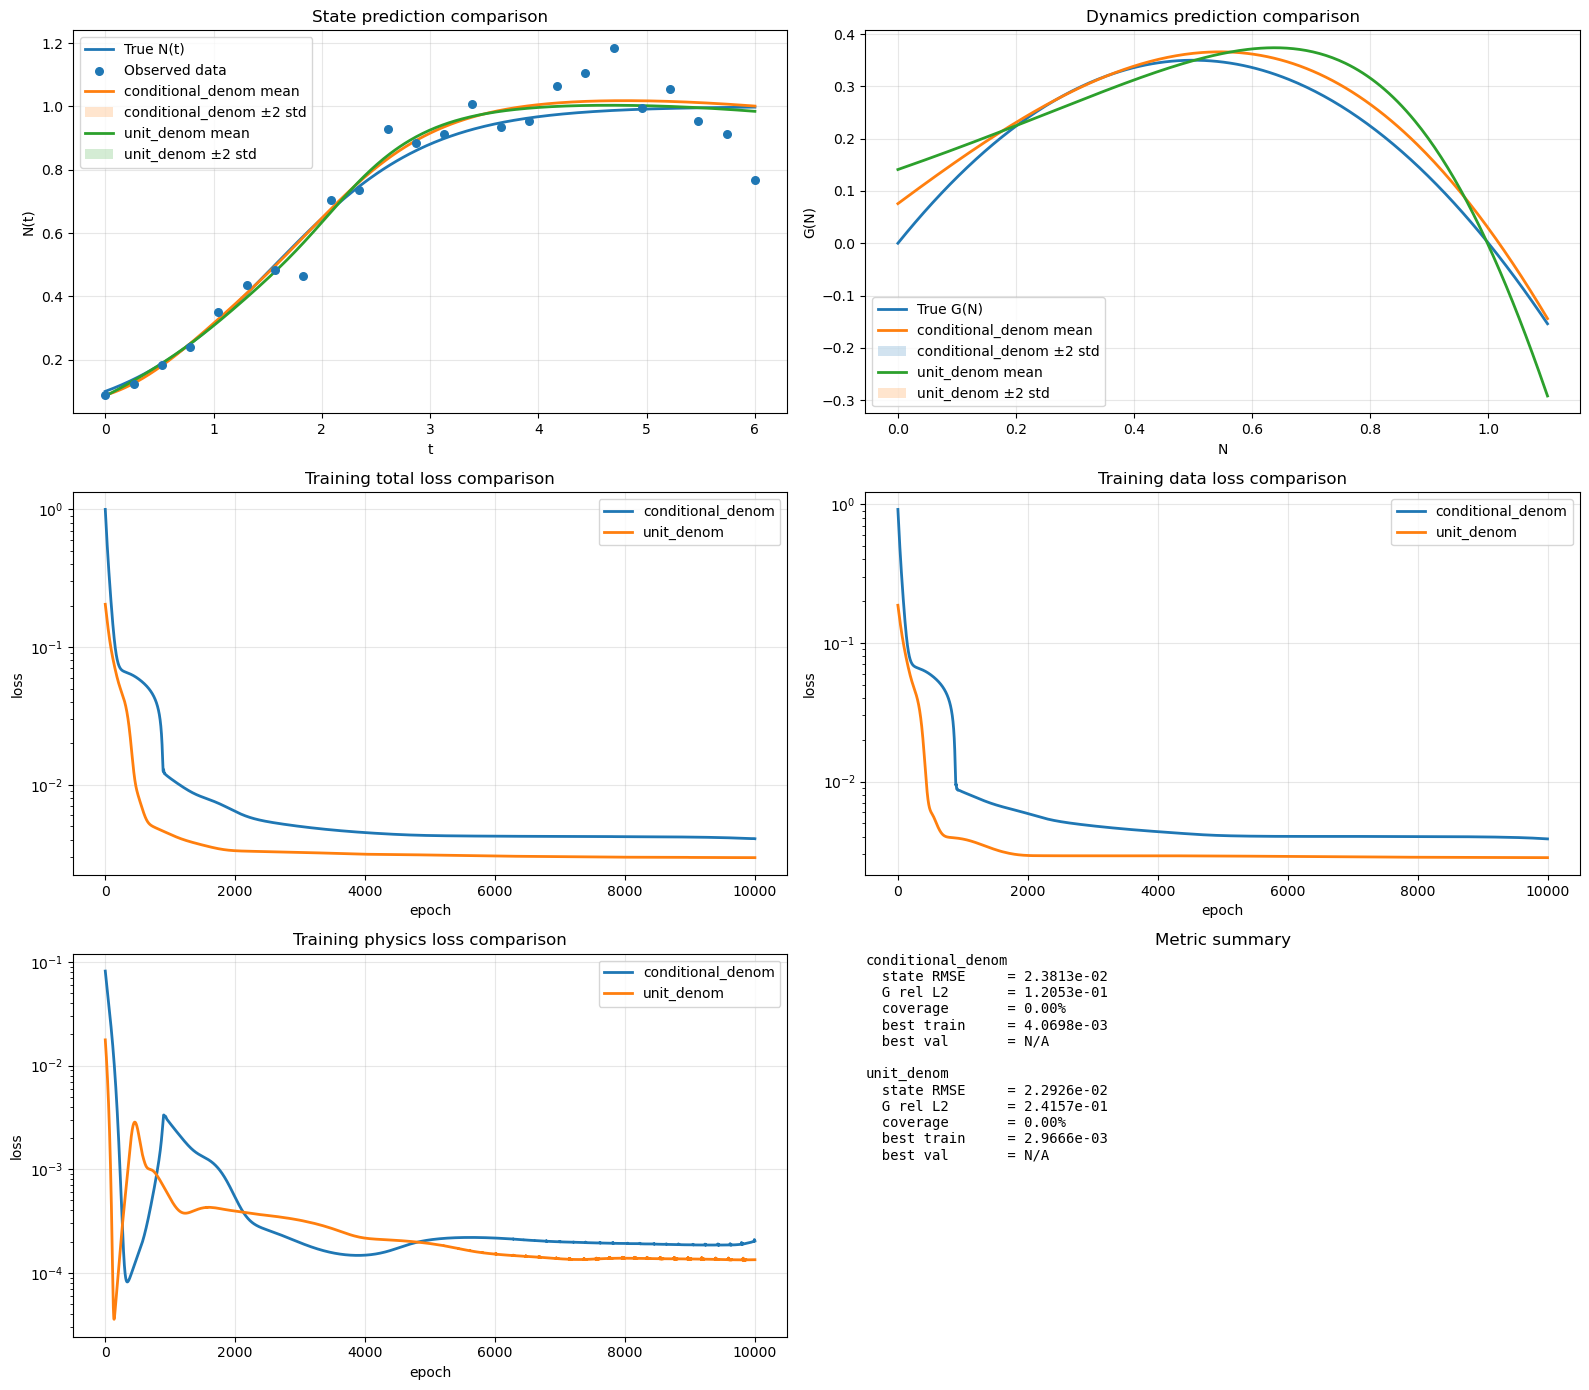

In [46]:
import copy
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# ============================================================
# Reproducibility / device
# ============================================================
torch.manual_seed(0)
np.random.seed(0)
device = torch.device("cpu")


# ============================================================
# 1. Ground-truth system: logistic growth dN/dt = r N (1 - N)
# ============================================================
r_true = 1.4
N0 = 0.1
numpts = 4 * (24 // 4)

t_obs = torch.linspace(0.0, 6.0, numpts, device=device).view(-1, 1)

def G_true(N):
    return r_true * N * (1.0 - N)


# ============================================================
# 2. Generate synthetic observed data
# ============================================================
def rk4_step(f, y, t, dt):
    k1 = f(t, y)
    k2 = f(t + 0.5 * dt, y + 0.5 * dt * k1)
    k3 = f(t + 0.5 * dt, y + 0.5 * dt * k2)
    k4 = f(t + dt, y + dt * k3)
    return y + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)

def odeint_rk4(f, y0, t):
    ys = [y0]
    y = y0
    for i in range(len(t) - 1):
        ti = t[i]
        dt = t[i + 1] - t[i]
        y = rk4_step(f, y, ti, dt)
        ys.append(y)
    return torch.stack(ys, dim=0)

with torch.no_grad():
    y0_true = torch.tensor([[N0]], dtype=torch.float32, device=device)
    y_true = odeint_rk4(lambda t, y: G_true(y), y0_true, t_obs.squeeze()).squeeze(1)

torch.manual_seed(0)
y_data = y_true + 0.1 * torch.randn_like(y_true) * y_true


# ============================================================
# 3. Networks
# ============================================================
class SolutionNet(nn.Module):
    def __init__(self, hidden_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, t):
        return self.net(t)


class DynamicsNet(nn.Module):
    def __init__(self, hidden_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, N):
        return self.net(N)


# ============================================================
# 4. Helpers
# ============================================================
def l2_prior_loss(model, sigma_prior=1.0):
    loss = 0.0
    nblocks = 0
    for p in model.parameters():
        loss = loss + 0.5 * torch.mean((p / sigma_prior) ** 2)
        nblocks += 1
    return loss / max(nblocks, 1)

def grad_wrt_t(y, t):
    return torch.autograd.grad(
        outputs=y,
        inputs=t,
        grad_outputs=torch.ones_like(y),
        create_graph=True,
        retain_graph=True,
    )[0]


# ============================================================
# 5. Standard deterministic PINN losses
#    Two variants:
#      - "conditional": divide by N_obs if N_obs > threshold else divide by 1
#      - "unit": always divide by 1
# ============================================================
t_phys = torch.linspace(0.0, 6.0, 300, device=device).view(-1, 1)

def compute_pinn_losses(sol_net, dyn_net,
                        t_data, y_data,
                        t_phys,
                        loss_mode="conditional",
                        denom_threshold=0.01,
                        lambda_phys=1.0,
                        lambda_prior=0.0):
    with torch.enable_grad():
        # ----- data loss -----
        N_obs = sol_net(t_data)

        if loss_mode == "conditional":
            denom = torch.where(N_obs > denom_threshold, N_obs, torch.ones_like(N_obs))
        elif loss_mode == "unit":
            denom = torch.ones_like(N_obs)
        else:
            raise ValueError(f"Unknown loss_mode={loss_mode}")

        data_loss = 0.5 * torch.mean(((N_obs - y_data) / denom) ** 2)

        # ----- physics loss -----
        t_phys_req = t_phys.clone().detach().requires_grad_(True)
        N_phys = sol_net(t_phys_req)
        dN_dt = torch.autograd.grad(
            outputs=N_phys,
            inputs=t_phys_req,
            grad_outputs=torch.ones_like(N_phys),
            create_graph=True,
            retain_graph=True,
        )[0]
        G_phys = dyn_net(N_phys)
        physics_loss = 0.5 * torch.mean((dN_dt - G_phys) ** 2)

        # ----- prior loss -----
        prior_sol = l2_prior_loss(sol_net, sigma_prior=1.0)
        prior_dyn = l2_prior_loss(dyn_net, sigma_prior=1.0)
        prior_loss = prior_sol + prior_dyn

        total = data_loss + lambda_phys * physics_loss + lambda_prior * prior_loss

    return {
        "total": total,
        "data": data_loss,
        "physics": physics_loss,
        "prior": prior_loss,
    }

def evaluate_on_split(sol_net, dyn_net,
                      t_eval, y_eval,
                      t_phys,
                      loss_mode="conditional",
                      denom_threshold=0.01,
                      lambda_phys=1.0,
                      lambda_prior=0.0):
    if t_eval is None or y_eval is None or len(t_eval) == 0:
        return {
            "total": np.nan,
            "data": np.nan,
            "physics": np.nan,
            "prior": np.nan,
        }

    with torch.enable_grad():
        losses = compute_pinn_losses(
            sol_net, dyn_net,
            t_eval, y_eval,
            t_phys,
            loss_mode=loss_mode,
            denom_threshold=denom_threshold,
            lambda_phys=lambda_phys,
            lambda_prior=lambda_prior,
        )
    return {k: float(v.detach().cpu()) for k, v in losses.items()}


# ============================================================
# 6. Additional evaluation on true N and true G
# ============================================================
def evaluate_true_errors(sol_net, dyn_net, t_plot, y_true_dense, N_grid, G_exact):
    with torch.no_grad():
        N_pred = sol_net(t_plot).squeeze(-1)
        G_pred = dyn_net(N_grid).squeeze(-1)

        err_N_rmse = torch.sqrt(torch.mean((N_pred - y_true_dense.squeeze(-1)) ** 2)).item()
        err_N_rel_l2 = (
            torch.norm(N_pred - y_true_dense.squeeze(-1)) /
            (torch.norm(y_true_dense.squeeze(-1)) + 1e-12)
        ).item()

        err_G_rmse = torch.sqrt(torch.mean((G_pred - G_exact) ** 2)).item()
        err_G_rel_l2 = (
            torch.norm(G_pred - G_exact) /
            (torch.norm(G_exact) + 1e-12)
        ).item()

    return {
        "N_rmse": err_N_rmse,
        "N_rel_l2": err_N_rel_l2,
        "G_rmse": err_G_rmse,
        "G_rel_l2": err_G_rel_l2,
    }


# ============================================================
# 7. Training utility
#    Train two models simultaneously:
#      - conditional denom model
#      - unit denom model
# ============================================================
def train_two_pinn_models(
    model_specs,
    t_train, y_train,
    t_val, y_val,
    t_phys,
    t_plot, y_true_dense,
    N_grid, G_exact,
    lr=1e-3, epochs=4000,
    lambda_phys=1.0,
    lambda_prior=0.0,
    denom_threshold=0.01,
    verbose_every=500,
):
    has_validation = (t_val is not None) and (y_val is not None) and (len(t_val) > 0)

    for spec in model_specs.values():
        params = list(spec["sol_net"].parameters()) + list(spec["dyn_net"].parameters())
        spec["opt"] = torch.optim.Adam(params, lr=lr)
        spec["history"] = {
            "train_total": [], "train_data": [], "train_physics": [], "train_prior": [],
            "val_total": [], "val_data": [], "val_physics": [], "val_prior": [],
        }
        spec["best_score"] = float("inf")
        spec["best_val"] = np.nan
        spec["best_state"] = None
        spec["best_summary"] = None

    for ep in range(epochs):
        for name, spec in model_specs.items():
            sol_net = spec["sol_net"]
            dyn_net = spec["dyn_net"]
            opt = spec["opt"]
            loss_mode = spec["loss_mode"]

            opt.zero_grad()

            train_losses = compute_pinn_losses(
                sol_net, dyn_net,
                t_train, y_train,
                t_phys,
                loss_mode=loss_mode,
                denom_threshold=denom_threshold,
                lambda_phys=lambda_phys,
                lambda_prior=lambda_prior,
            )
            train_losses["total"].backward()
            opt.step()

            if has_validation:
                val_losses = evaluate_on_split(
                    sol_net, dyn_net,
                    t_val, y_val,
                    t_phys,
                    loss_mode=loss_mode,
                    denom_threshold=denom_threshold,
                    lambda_phys=lambda_phys,
                    lambda_prior=lambda_prior,
                )
                selection_score = val_losses["total"]
            else:
                val_losses = {
                    "total": np.nan,
                    "data": np.nan,
                    "physics": np.nan,
                    "prior": np.nan,
                }
                selection_score = train_losses["total"].item()

            spec["history"]["train_total"].append(train_losses["total"].item())
            spec["history"]["train_data"].append(train_losses["data"].item())
            spec["history"]["train_physics"].append(train_losses["physics"].item())
            spec["history"]["train_prior"].append(train_losses["prior"].item())

            spec["history"]["val_total"].append(val_losses["total"])
            spec["history"]["val_data"].append(val_losses["data"])
            spec["history"]["val_physics"].append(val_losses["physics"])
            spec["history"]["val_prior"].append(val_losses["prior"])

            if selection_score < spec["best_score"]:
                spec["best_score"] = selection_score
                spec["best_val"] = val_losses["total"]

                true_errs = evaluate_true_errors(
                    sol_net, dyn_net, t_plot, y_true_dense, N_grid, G_exact
                )

                spec["best_state"] = {
                    "sol": copy.deepcopy(sol_net.state_dict()),
                    "dyn": copy.deepcopy(dyn_net.state_dict()),
                    "epoch": ep,
                }

                spec["best_summary"] = {
                    "epoch": ep,
                    "selection_metric": "val_total" if has_validation else "train_total",
                    "selection_score": selection_score,
                    "train_total": train_losses["total"].item(),
                    "train_data": train_losses["data"].item(),
                    "train_physics": train_losses["physics"].item(),
                    "train_prior": train_losses["prior"].item(),
                    "val_total": val_losses["total"],
                    "val_data": val_losses["data"],
                    "val_physics": val_losses["physics"],
                    "val_prior": val_losses["prior"],
                    "N_rmse": true_errs["N_rmse"],
                    "N_rel_l2": true_errs["N_rel_l2"],
                    "G_rmse": true_errs["G_rmse"],
                    "G_rel_l2": true_errs["G_rel_l2"],
                }

        if verbose_every is not None and ep % verbose_every == 0:
            msg = f"[ep={ep:5d}]"
            for name, spec in model_specs.items():
                tr = spec["history"]["train_total"][-1]
                td = spec["history"]["train_data"][-1]
                tp = spec["history"]["train_physics"][-1]
                if has_validation:
                    va = spec["history"]["val_total"][-1]
                    msg += (
                        f" | {name}: "
                        f"train={tr:.4e} (data={td:.4e}, phys={tp:.4e}) "
                        f"val={va:.4e}"
                    )
                else:
                    msg += (
                        f" | {name}: "
                        f"train={tr:.4e} (data={td:.4e}, phys={tp:.4e}) "
                        f"val=N/A"
                    )
            print(msg, end="\r")

    for spec in model_specs.values():
        spec["sol_net"].load_state_dict(spec["best_state"]["sol"])
        spec["dyn_net"].load_state_dict(spec["best_state"]["dyn"])

    return model_specs


# ============================================================
# 8. Train/validation split generator
# ============================================================
def make_random_splits(n, n_splits=10, val_fraction=0.25, seed=0):
    rng = np.random.default_rng(seed)
    indices = np.arange(n)
    splits = []

    if val_fraction <= 0:
        for _ in range(n_splits):
            train_idx = np.sort(indices.copy())
            val_idx = np.array([], dtype=int)
            splits.append((train_idx, val_idx))
        return splits

    n_val = int(round(val_fraction * n))
    n_val = min(max(n_val, 1), n - 1)

    for _ in range(n_splits):
        perm = rng.permutation(indices)
        val_idx = np.sort(perm[:n_val])
        train_idx = np.sort(perm[n_val:])
        splits.append((train_idx, val_idx))

    return splits


# ============================================================
# 9. Experiment settings
# ============================================================
hidden_dim = 4
n_splits = 1
epochs = 10000
lambda_phys = 1.0
lambda_prior = 0.0
denom_threshold = 0.01

model_configs = {
    "conditional_denom": {
        "loss_mode": "conditional",
    },
    "unit_denom": {
        "loss_mode": "unit",
    },
}

splits = make_random_splits(
    len(t_obs),
    n_splits=n_splits,
    val_fraction=0,
    seed=123
)

# dense truth objects needed during training summaries
t_plot = torch.linspace(0.0, 6.0, 400, device=device).view(-1, 1)
with torch.no_grad():
    y_true_dense = odeint_rk4(
        lambda t, y: G_true(y),
        torch.tensor([[N0]], dtype=torch.float32, device=device),
        t_plot.squeeze()
    ).squeeze(1)

    N_grid = torch.linspace(
        0.0,
        max(1.1, float(torch.max(y_true_dense).cpu()) + 0.05),
        300,
        device=device
    ).view(-1, 1)
    G_exact = G_true(N_grid).squeeze(-1)


# ============================================================
# 10. Storage for results
# ============================================================
results = {}
for model_name in model_configs.keys():
    results[model_name] = {
        "ensemble_solutions": [],
        "ensemble_dynamics": [],
        "ensemble_histories": [],
        "split_metrics": [],
    }


# ============================================================
# 11. Train across splits
# ============================================================
for i, (train_idx, val_idx) in enumerate(splits):
    print(f"\nTraining split {i+1}/{n_splits}")

    t_train = t_obs[train_idx]
    y_train = y_data[train_idx]

    t_val = t_obs[val_idx]
    y_val = y_data[val_idx]

    model_specs = {}
    for model_name, cfg in model_configs.items():
        model_specs[model_name] = {
            "loss_mode": cfg["loss_mode"],
            "sol_net": SolutionNet(hidden_dim=hidden_dim).to(device),
            "dyn_net": DynamicsNet(hidden_dim=hidden_dim).to(device),
        }

    model_specs = train_two_pinn_models(
        model_specs,
        t_train, y_train,
        t_val, y_val,
        t_phys,
        t_plot, y_true_dense,
        N_grid, G_exact,
        lr=1e-3,
        epochs=epochs,
        lambda_phys=lambda_phys,
        lambda_prior=lambda_prior,
        denom_threshold=denom_threshold,
        verbose_every=500,
    )

    for model_name, spec in model_specs.items():
        best_summary = spec["best_summary"]
        best_epoch = spec["best_state"]["epoch"]

        results[model_name]["ensemble_solutions"].append(copy.deepcopy(spec["sol_net"]))
        results[model_name]["ensemble_dynamics"].append(copy.deepcopy(spec["dyn_net"]))
        results[model_name]["ensemble_histories"].append(spec["history"])
        results[model_name]["split_metrics"].append({
            "split": i,
            "loss_mode": spec["loss_mode"],
            "selection_metric": best_summary["selection_metric"],
            "selection_score": best_summary["selection_score"],
            "best_val_total": best_summary["val_total"],
            "best_train_total_at_best_val": best_summary["train_total"],
            "best_epoch": best_summary["epoch"],
            "best_val_data": best_summary["val_data"],
            "best_val_physics": best_summary["val_physics"],
            "best_val_prior": best_summary["val_prior"],
            "best_train_data": best_summary["train_data"],
            "best_train_physics": best_summary["train_physics"],
            "best_train_prior": best_summary["train_prior"],
            "N_rmse": best_summary["N_rmse"],
            "N_rel_l2": best_summary["N_rel_l2"],
            "G_rmse": best_summary["G_rmse"],
            "G_rel_l2": best_summary["G_rel_l2"],
            "n_train": len(train_idx),
            "n_val": len(val_idx),
            "train_idx": train_idx,
            "val_idx": val_idx,
        })

        if len(val_idx) > 0:
            print(
                f"{model_name:18s} | best epoch = {best_epoch:5d} | "
                f"val total = {best_summary['val_total']:.6e} | "
                f"train total = {best_summary['train_total']:.6e}"
            )
        else:
            print(
                f"{model_name:18s} | best epoch = {best_epoch:5d} | "
                f"no validation set, selected by train total = {best_summary['train_total']:.6e}"
            )


# ============================================================
# 12. Aggregate helpers
# ============================================================
def aggregate_histories(histories, key):
    arr = np.array([h[key] for h in histories], dtype=float)
    return np.nanmean(arr, axis=0), np.nanstd(arr, axis=0), arr

def summarize_model_result(model_name, model_result):
    ensemble_solutions = model_result["ensemble_solutions"]
    ensemble_dynamics = model_result["ensemble_dynamics"]
    split_metrics = model_result["split_metrics"]

    with torch.no_grad():
        N_ensemble = []
        for sol_net in ensemble_solutions:
            N_ensemble.append(sol_net(t_plot).squeeze(-1))
        N_ensemble = torch.stack(N_ensemble, dim=0)

        N_mean = N_ensemble.mean(dim=0)
        N_std = N_ensemble.std(dim=0)

        G_ensemble = []
        for dyn_net in ensemble_dynamics:
            G_ensemble.append(dyn_net(N_grid).squeeze(-1))
        G_ensemble = torch.stack(G_ensemble, dim=0)

        G_mean = G_ensemble.mean(dim=0)
        G_std = G_ensemble.std(dim=0)

        lower = N_mean - 2.0 * N_std
        upper = N_mean + 2.0 * N_std
        coverage = (
            (y_true_dense.squeeze(-1) >= lower) &
            (y_true_dense.squeeze(-1) <= upper)
        ).float().mean().item()

        rmse_state = torch.sqrt(
            torch.mean((N_mean - y_true_dense.squeeze(-1)) ** 2)
        ).item()

        rel_l2_G = (torch.norm(G_mean - G_exact) / torch.norm(G_exact)).item()

    has_any_validation = any(m["n_val"] > 0 for m in split_metrics)
    best_by_train = min(split_metrics, key=lambda m: m["best_train_total_at_best_val"])
    best_by_val = None
    if has_any_validation:
        valid_split_metrics = [m for m in split_metrics if m["n_val"] > 0]
        best_by_val = min(valid_split_metrics, key=lambda m: m["best_val_total"])

    history_stats = {}
    for k in [
        "train_total", "train_data", "train_physics", "train_prior",
        "val_total", "val_data", "val_physics", "val_prior"
    ]:
        history_stats[k] = aggregate_histories(model_result["ensemble_histories"], k)

    return {
        "N_mean": N_mean,
        "N_std": N_std,
        "G_mean": G_mean,
        "G_std": G_std,
        "coverage": coverage,
        "rmse_state": rmse_state,
        "rel_l2_G": rel_l2_G,
        "has_any_validation": has_any_validation,
        "best_by_train": best_by_train,
        "best_by_val": best_by_val,
        "history_stats": history_stats,
        "epochs_axis": np.arange(len(model_result["ensemble_histories"][0]["train_total"])),
    }


summaries = {name: summarize_model_result(name, res) for name, res in results.items()}


# ============================================================
# 13. Printed summaries
# ============================================================
for model_name, model_result in results.items():
    summary = summaries[model_name]
    split_metrics = model_result["split_metrics"]

    print(f"\n================ {model_name} ================")
    print(f"Number of splits                    : {n_splits}")
    print(f"Validation used                     : {summary['has_any_validation']}")
    if summary["has_any_validation"]:
        print(f"Mean best validation loss           : {np.nanmean([m['best_val_total'] for m in split_metrics]):.6e}")
        print(f"Std  best validation loss           : {np.nanstd([m['best_val_total'] for m in split_metrics]):.6e}")
    else:
        print("Mean best validation loss           : N/A")
        print("Std  best validation loss           : N/A")
    print(f"Mean training loss @ saved model    : {np.mean([m['best_train_total_at_best_val'] for m in split_metrics]):.6e}")
    print(f"Mean best epoch                     : {np.mean([m['best_epoch'] for m in split_metrics]):.2f}")
    print(f"Mean N RMSE (saved models)          : {np.mean([m['N_rmse'] for m in split_metrics]):.6e}")
    print(f"Mean N rel L2 (saved models)        : {np.mean([m['N_rel_l2'] for m in split_metrics]):.6e}")
    print(f"Mean G RMSE (saved models)          : {np.mean([m['G_rmse'] for m in split_metrics]):.6e}")
    print(f"Mean G rel L2 (saved models)        : {np.mean([m['G_rel_l2'] for m in split_metrics]):.6e}")
    print(f"State ensemble RMSE                 : {summary['rmse_state']:.6e}")
    print(f"G ensemble mean rel L2 error        : {summary['rel_l2_G']:.6e}")
    print(f"95% band coverage (~mean±2σ)        : {summary['coverage']*100:.2f}%")
    print("------------------------------------------------------")
    if summary["best_by_val"] is not None:
        print("Best split by validation loss:")
        print(f"  split                             : {summary['best_by_val']['split']}")
        print(f"  epoch                             : {summary['best_by_val']['best_epoch']}")
        print(f"  train total                       : {summary['best_by_val']['best_train_total_at_best_val']:.6e}")
        print(f"  val total                         : {summary['best_by_val']['best_val_total']:.6e}")
    else:
        print("Best split by validation loss       : N/A (no validation set)")
    print("------------------------------------------------------")
    print("Best split by training loss:")
    print(f"  split                             : {summary['best_by_train']['split']}")
    print(f"  epoch                             : {summary['best_by_train']['best_epoch']}")
    print(f"  train total                       : {summary['best_by_train']['best_train_total_at_best_val']:.6e}")
    if summary["best_by_train"]["n_val"] > 0:
        print(f"  val total                         : {summary['best_by_train']['best_val_total']:.6e}")
    else:
        print("  val total                         : N/A")
    print(f"  true N RMSE / rel L2              : "
          f"{summary['best_by_train']['N_rmse']:.6e} / {summary['best_by_train']['N_rel_l2']:.6e}")
    print(f"  true G RMSE / rel L2              : "
          f"{summary['best_by_train']['G_rmse']:.6e} / {summary['best_by_train']['G_rel_l2']:.6e}")
    print("======================================================")


# ============================================================
# 14. Comparison plots
# ============================================================
fig, axes = plt.subplots(3, 2, figsize=(16, 14))

# ------------------------------------------------------------
# (a) State ensemble comparison
# ------------------------------------------------------------
ax = axes[0, 0]
ax.plot(t_plot.cpu(), y_true_dense.cpu(), lw=2, label="True N(t)")
ax.scatter(t_obs.cpu(), y_data.cpu(), s=30, zorder=3, label="Observed data")

for model_name, summary in summaries.items():
    ax.plot(t_plot.cpu(), summary["N_mean"].cpu(), lw=2, label=f"{model_name} mean")
    ax.fill_between(
        t_plot.squeeze(-1).cpu().numpy(),
        (summary["N_mean"] - 2 * summary["N_std"]).cpu().numpy(),
        (summary["N_mean"] + 2 * summary["N_std"]).cpu().numpy(),
        alpha=0.20,
        label=f"{model_name} ±2 std"
    )

ax.set_title("State prediction comparison")
ax.set_xlabel("t")
ax.set_ylabel("N(t)")
ax.grid(True, alpha=0.3)
ax.legend()

# ------------------------------------------------------------
# (b) Dynamics ensemble comparison
# ------------------------------------------------------------
ax = axes[0, 1]
ax.plot(N_grid.cpu(), G_exact.cpu(), lw=2, label="True G(N)")

for model_name, summary in summaries.items():
    ax.plot(N_grid.cpu(), summary["G_mean"].cpu(), lw=2, label=f"{model_name} mean")
    ax.fill_between(
        N_grid.squeeze(-1).cpu().numpy(),
        (summary["G_mean"] - 2 * summary["G_std"]).cpu().numpy(),
        (summary["G_mean"] + 2 * summary["G_std"]).cpu().numpy(),
        alpha=0.20,
        label=f"{model_name} ±2 std"
    )

ax.set_title("Dynamics prediction comparison")
ax.set_xlabel("N")
ax.set_ylabel("G(N)")
ax.grid(True, alpha=0.3)
ax.legend()

# ------------------------------------------------------------
# (c) Training total loss comparison
# ------------------------------------------------------------
ax = axes[1, 0]
for model_name, summary in summaries.items():
    mean_train, std_train, _ = summary["history_stats"]["train_total"]
    epochs_axis = summary["epochs_axis"]
    ax.plot(epochs_axis, mean_train, lw=2, label=model_name)
    ax.fill_between(
        epochs_axis,
        np.maximum(mean_train - std_train, 1e-12),
        mean_train + std_train,
        alpha=0.15
    )
ax.set_yscale("log")
ax.set_title("Training total loss comparison")
ax.set_xlabel("epoch")
ax.set_ylabel("loss")
ax.grid(True, alpha=0.3)
ax.legend()

# ------------------------------------------------------------
# (d) Training data loss comparison
# ------------------------------------------------------------
ax = axes[1, 1]
for model_name, summary in summaries.items():
    mean_data, std_data, _ = summary["history_stats"]["train_data"]
    epochs_axis = summary["epochs_axis"]
    ax.plot(epochs_axis, mean_data, lw=2, label=model_name)
    ax.fill_between(
        epochs_axis,
        np.maximum(mean_data - std_data, 1e-12),
        mean_data + std_data,
        alpha=0.15
    )
ax.set_yscale("log")
ax.set_title("Training data loss comparison")
ax.set_xlabel("epoch")
ax.set_ylabel("loss")
ax.grid(True, alpha=0.3)
ax.legend()

# ------------------------------------------------------------
# (e) Training physics loss comparison
# ------------------------------------------------------------
ax = axes[2, 0]
for model_name, summary in summaries.items():
    mean_phys, std_phys, _ = summary["history_stats"]["train_physics"]
    epochs_axis = summary["epochs_axis"]
    ax.plot(epochs_axis, mean_phys, lw=2, label=model_name)
    ax.fill_between(
        epochs_axis,
        np.maximum(mean_phys - std_phys, 1e-12),
        mean_phys + std_phys,
        alpha=0.15
    )
ax.set_yscale("log")
ax.set_title("Training physics loss comparison")
ax.set_xlabel("epoch")
ax.set_ylabel("loss")
ax.grid(True, alpha=0.3)
ax.legend()

# ------------------------------------------------------------
# (f) Final metric comparison text panel
# ------------------------------------------------------------
ax = axes[2, 1]
ax.axis("off")

text_lines = []
for model_name, summary in summaries.items():
    text_lines.append(model_name)
    text_lines.append(f"  state RMSE     = {summary['rmse_state']:.4e}")
    text_lines.append(f"  G rel L2       = {summary['rel_l2_G']:.4e}")
    text_lines.append(f"  coverage       = {summary['coverage']*100:.2f}%")
    text_lines.append(f"  best train     = {summary['best_by_train']['best_train_total_at_best_val']:.4e}")
    if summary["best_by_val"] is not None:
        text_lines.append(f"  best val       = {summary['best_by_val']['best_val_total']:.4e}")
    else:
        text_lines.append("  best val       = N/A")
    text_lines.append("")

ax.text(
    0.0, 1.0,
    "\n".join(text_lines),
    va="top",
    ha="left",
    family="monospace"
)
ax.set_title("Metric summary")

plt.tight_layout()
plt.show()


Training split 1/1
[ep= 9500] | conditional_denom: train=4.1444e-03 (data=3.9587e-03, phys=1.8566e-04) val=N/A | unit_denom: train=2.9718e-03 (data=2.8373e-03, phys=1.3450e-04) val=N/A

conditional_denom  | best epoch =  9994 | no validation set, train total = 4.069816e-03
unit_denom         | best epoch =  9999 | no validation set, train total = 2.966568e-03

================ conditional_denom ================
Validation used                     : False
State ensemble RMSE                 : 2.381303e-02
G ensemble mean rel L2 error        : 1.205295e-01

================ unit_denom ================
Validation used                     : False
State ensemble RMSE                 : 2.292554e-02
G ensemble mean rel L2 error        : 2.415749e-01


/var/folders/dn/jj6zl9nx6s541bq88x9x4zvm0000gn/T/ipykernel_99265/4190406341.py:429: RuntimeWarning: Mean of empty slice
  return np.nanmean(arr, axis=0), np.nanstd(arr, axis=0), arr


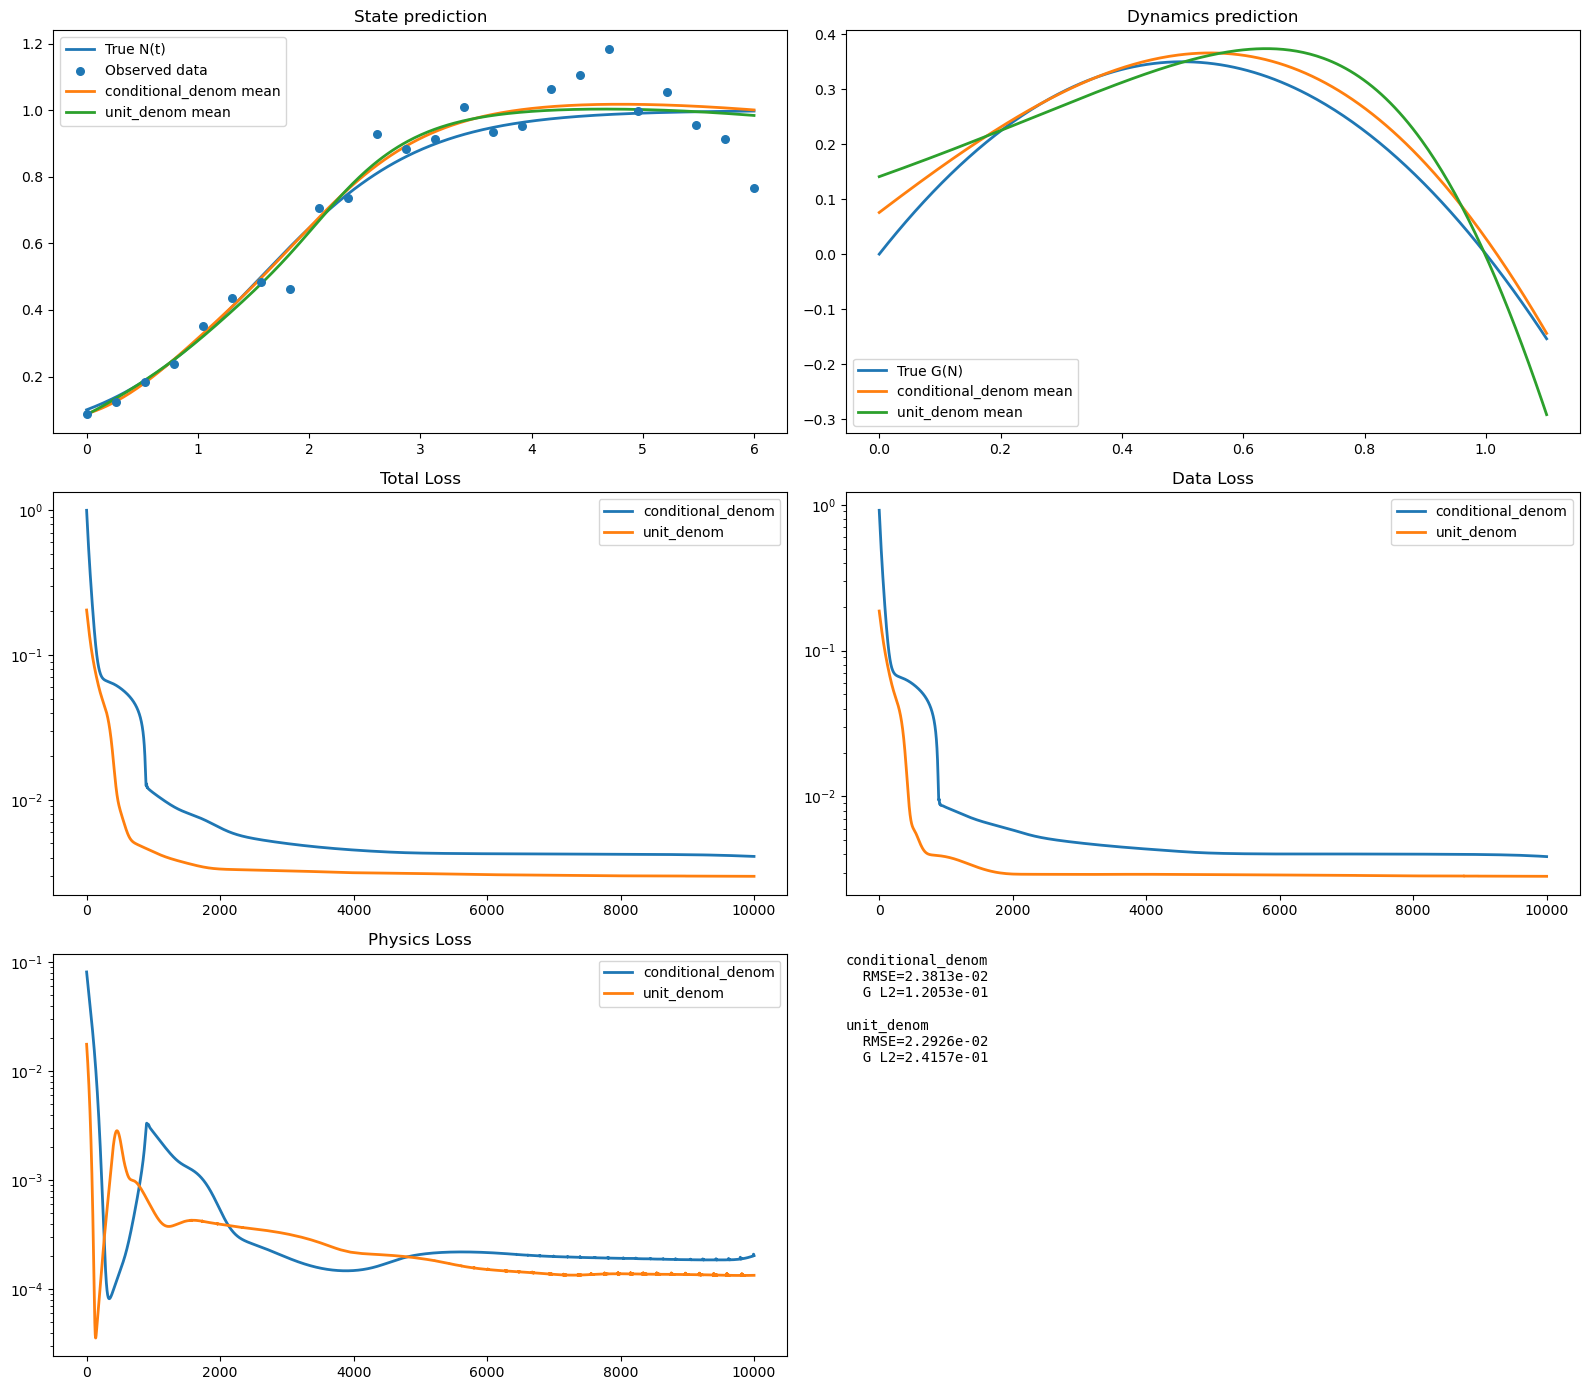

In [62]:
import copy
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# ============================================================
# Reproducibility / device
# ============================================================
torch.manual_seed(0)
np.random.seed(0)
device = torch.device("cpu")


# ============================================================
# 1. Ground-truth system: logistic growth dN/dt = r N (1 - N)
# ============================================================
r_true = 1.4
N0 = 0.1
numpts = 4 * (24 // 4)

t_obs = torch.linspace(0.0, 6.0, numpts, device=device).view(-1, 1)

def G_true(N):
    return r_true * N * (1.0 - N)


# ============================================================
# 2. Generate synthetic observed data
# ============================================================
def rk4_step(f, y, t, dt):
    k1 = f(t, y)
    k2 = f(t + 0.5 * dt, y + 0.5 * dt * k1)
    k3 = f(t + 0.5 * dt, y + 0.5 * dt * k2)
    k4 = f(t + dt, y + dt * k3)
    return y + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)

def odeint_rk4(f, y0, t):
    ys = [y0]
    y = y0
    for i in range(len(t) - 1):
        ti = t[i]
        dt = t[i + 1] - t[i]
        y = rk4_step(f, y, ti, dt)
        ys.append(y)
    return torch.stack(ys, dim=0)

with torch.no_grad():
    y0_true = torch.tensor([[N0]], dtype=torch.float32, device=device)
    y_true = odeint_rk4(lambda t, y: G_true(y), y0_true, t_obs.squeeze()).squeeze(1)

torch.manual_seed(0)
y_data = y_true + 0.1 * torch.randn_like(y_true) * y_true


# ============================================================
# 3. Networks
# ============================================================
class SolutionNet(nn.Module):
    def __init__(self, hidden_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, t):
        return self.net(t)


class DynamicsNet(nn.Module):
    def __init__(self, hidden_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, N):
        return self.net(N)


# ============================================================
# 4. Helpers
# ============================================================
def l2_prior_loss(model, sigma_prior=1.0):
    loss = 0.0
    nblocks = 0
    for p in model.parameters():
        loss = loss + 0.5 * torch.mean((p / sigma_prior) ** 2)
        nblocks += 1
    return loss / max(nblocks, 1)

def grad_wrt_t(y, t):
    return torch.autograd.grad(
        outputs=y,
        inputs=t,
        grad_outputs=torch.ones_like(y),
        create_graph=True,
        retain_graph=True,
    )[0]


# ============================================================
# 5. PINN losses
# ============================================================
t_phys = torch.linspace(0.0, 6.0, 300, device=device).view(-1, 1)

def compute_pinn_losses(sol_net, dyn_net, t_data, y_data, t_phys,
                        loss_mode="conditional", denom_threshold=0.01,
                        lambda_phys=1.0, lambda_prior=0.0):
    with torch.enable_grad():
        # Data loss
        N_obs = sol_net(t_data)
        if loss_mode == "conditional":
            denom = torch.where(N_obs > denom_threshold, N_obs, torch.ones_like(N_obs))
        elif loss_mode == "unit":
            denom = torch.ones_like(N_obs)
        else:
            raise ValueError(f"Unknown loss_mode={loss_mode}")
        data_loss = 0.5 * torch.mean(((N_obs - y_data) / denom) ** 2)

        # Physics loss
        t_phys_req = t_phys.clone().detach().requires_grad_(True)
        N_phys = sol_net(t_phys_req)
        dN_dt = torch.autograd.grad(
            outputs=N_phys,
            inputs=t_phys_req,
            grad_outputs=torch.ones_like(N_phys),
            create_graph=True,
            retain_graph=True,
        )[0]
        G_phys = dyn_net(N_phys)
        physics_loss = 0.5 * torch.mean((dN_dt - G_phys) ** 2)

        # Prior loss
        prior_sol = l2_prior_loss(sol_net, sigma_prior=1.0)
        prior_dyn = l2_prior_loss(dyn_net, sigma_prior=1.0)
        prior_loss = prior_sol + prior_dyn

        total = data_loss + lambda_phys * physics_loss + lambda_prior * prior_loss

    return {
        "total": total, "data": data_loss, 
        "physics": physics_loss, "prior": prior_loss,
    }

def evaluate_on_split(sol_net, dyn_net, t_eval, y_eval, t_phys,
                      loss_mode="conditional", denom_threshold=0.01,
                      lambda_phys=1.0, lambda_prior=0.0):
    if t_eval is None or y_eval is None or len(t_eval) == 0:
        return {"total": np.nan, "data": np.nan, "physics": np.nan, "prior": np.nan}
    with torch.enable_grad():
        losses = compute_pinn_losses(
            sol_net, dyn_net, t_eval, y_eval, t_phys,
            loss_mode=loss_mode, denom_threshold=denom_threshold,
            lambda_phys=lambda_phys, lambda_prior=lambda_prior,
        )
    return {k: float(v.detach().cpu()) for k, v in losses.items()}


# ============================================================
# 6. Additional evaluation
# ============================================================
def evaluate_true_errors(sol_net, dyn_net, t_plot, y_true_dense, N_grid, G_exact):
    with torch.no_grad():
        N_pred = sol_net(t_plot).squeeze(-1)
        G_pred = dyn_net(N_grid).squeeze(-1)

        err_N_rmse = torch.sqrt(torch.mean((N_pred - y_true_dense.squeeze(-1)) ** 2)).item()
        err_N_rel_l2 = (torch.norm(N_pred - y_true_dense.squeeze(-1)) / (torch.norm(y_true_dense.squeeze(-1)) + 1e-12)).item()
        err_G_rmse = torch.sqrt(torch.mean((G_pred - G_exact) ** 2)).item()
        err_G_rel_l2 = (torch.norm(G_pred - G_exact) / (torch.norm(G_exact) + 1e-12)).item()

    return {
        "N_rmse": err_N_rmse, "N_rel_l2": err_N_rel_l2,
        "G_rmse": err_G_rmse, "G_rel_l2": err_G_rel_l2,
    }


# ============================================================
# 7. Training utility
# ============================================================
def train_two_pinn_models(
    model_specs, t_train, y_train, t_val, y_val, t_phys,
    t_plot, y_true_dense, N_grid, G_exact,
    lr=1e-3, epochs=4000, lambda_phys=1.0, lambda_prior=0.0,
    denom_threshold=0.01, verbose_every=500,
):
    has_validation = (t_val is not None) and (y_val is not None) and (len(t_val) > 0)

    for spec in model_specs.values():
        params = list(spec["sol_net"].parameters()) + list(spec["dyn_net"].parameters())
        spec["opt"] = torch.optim.Adam(params, lr=lr)
        spec["history"] = {
            "train_total": [], "train_data": [], "train_physics": [], "train_prior": [],
            "val_total": [], "val_data": [], "val_physics": [], "val_prior": [],
        }
        spec["best_score"] = float("inf")
        spec["best_val"] = np.nan
        spec["best_state"] = {
            "sol": copy.deepcopy(spec["sol_net"].state_dict()),
            "dyn": copy.deepcopy(spec["dyn_net"].state_dict()),
            "epoch": -1,
        }

        with torch.enable_grad():
            init_losses = compute_pinn_losses(
                spec["sol_net"], spec["dyn_net"], t_train, y_train, t_phys,
                loss_mode=spec["loss_mode"], denom_threshold=denom_threshold,
                lambda_phys=lambda_phys, lambda_prior=lambda_prior,
            )

        init_true_errs = evaluate_true_errors(
            spec["sol_net"], spec["dyn_net"], t_plot, y_true_dense, N_grid, G_exact
        )

        spec["best_summary"] = {
            "epoch": -1,
            "selection_metric": "val_total" if has_validation else "train_total",
            "selection_score": float("inf"),
            "train_total": init_losses["total"].item(),
            "train_data": init_losses["data"].item(),
            "train_physics": init_losses["physics"].item(),
            "train_prior": init_losses["prior"].item(),
            "val_total": np.nan, "val_data": np.nan, "val_physics": np.nan, "val_prior": np.nan,
            "N_rmse": init_true_errs["N_rmse"], "N_rel_l2": init_true_errs["N_rel_l2"],
            "G_rmse": init_true_errs["G_rmse"], "G_rel_l2": init_true_errs["G_rel_l2"],
        }

    for ep in range(epochs):
        for name, spec in model_specs.items():
            sol_net = spec["sol_net"]
            dyn_net = spec["dyn_net"]
            opt = spec["opt"]
            loss_mode = spec["loss_mode"]

            opt.zero_grad()
            train_losses = compute_pinn_losses(
                sol_net, dyn_net, t_train, y_train, t_phys,
                loss_mode=loss_mode, denom_threshold=denom_threshold,
                lambda_phys=lambda_phys, lambda_prior=lambda_prior,
            )
            train_losses["total"].backward()
            opt.step()

            if has_validation:
                val_losses = evaluate_on_split(
                    sol_net, dyn_net, t_val, y_val, t_phys,
                    loss_mode=loss_mode, denom_threshold=denom_threshold,
                    lambda_phys=lambda_phys, lambda_prior=lambda_prior,
                )
                selection_score = val_losses["total"]
            else:
                val_losses = {"total": np.nan, "data": np.nan, "physics": np.nan, "prior": np.nan}
                selection_score = train_losses["total"].item()

            spec["history"]["train_total"].append(train_losses["total"].item())
            spec["history"]["train_data"].append(train_losses["data"].item())
            spec["history"]["train_physics"].append(train_losses["physics"].item())
            spec["history"]["train_prior"].append(train_losses["prior"].item())

            spec["history"]["val_total"].append(val_losses["total"])
            spec["history"]["val_data"].append(val_losses["data"])
            spec["history"]["val_physics"].append(val_losses["physics"])
            spec["history"]["val_prior"].append(val_losses["prior"])

            if selection_score < spec["best_score"]:
                spec["best_score"] = selection_score
                spec["best_val"] = val_losses["total"]
                true_errs = evaluate_true_errors(sol_net, dyn_net, t_plot, y_true_dense, N_grid, G_exact)
                spec["best_state"] = {
                    "sol": copy.deepcopy(sol_net.state_dict()),
                    "dyn": copy.deepcopy(dyn_net.state_dict()),
                    "epoch": ep,
                }
                spec["best_summary"] = {
                    "epoch": ep,
                    "selection_metric": "val_total" if has_validation else "train_total",
                    "selection_score": selection_score,
                    "train_total": train_losses["total"].item(),
                    "train_data": train_losses["data"].item(),
                    "train_physics": train_losses["physics"].item(),
                    "train_prior": train_losses["prior"].item(),
                    "val_total": val_losses["total"], "val_data": val_losses["data"],
                    "val_physics": val_losses["physics"], "val_prior": val_losses["prior"],
                    "N_rmse": true_errs["N_rmse"], "N_rel_l2": true_errs["N_rel_l2"],
                    "G_rmse": true_errs["G_rmse"], "G_rel_l2": true_errs["G_rel_l2"],
                }

        if verbose_every is not None and ep % verbose_every == 0:
            msg = f"[ep={ep:5d}]"
            for name, spec in model_specs.items():
                tr = spec["history"]["train_total"][-1]
                td = spec["history"]["train_data"][-1]
                tp = spec["history"]["train_physics"][-1]
                if has_validation:
                    va = spec["history"]["val_total"][-1]
                    msg += f" | {name}: train={tr:.4e} (data={td:.4e}, phys={tp:.4e}) val={va:.4e}"
                else:
                    msg += f" | {name}: train={tr:.4e} (data={td:.4e}, phys={tp:.4e}) val=N/A"
            print(msg, end="\r")

    print("\n")
    for spec in model_specs.values():
        spec["sol_net"].load_state_dict(spec["best_state"]["sol"])
        spec["dyn_net"].load_state_dict(spec["best_state"]["dyn"])

    return model_specs


# ============================================================
# 8. Train/validation split generator
# ============================================================
def make_random_splits(n, n_splits=10, val_fraction=0.25, seed=0):
    rng = np.random.default_rng(seed)
    indices = np.arange(n)
    splits = []

    if val_fraction <= 0:
        for _ in range(n_splits):
            splits.append((np.sort(indices.copy()), np.array([], dtype=int)))
        return splits

    n_val = min(max(int(round(val_fraction * n)), 1), n - 1)
    for _ in range(n_splits):
        perm = rng.permutation(indices)
        splits.append((np.sort(perm[n_val:]), np.sort(perm[:n_val])))
    return splits


# ============================================================
# 9. Experiment settings
# ============================================================
hidden_dim = 4
n_splits = 1
epochs = 10000
lambda_phys = 1.0
lambda_prior = 0.0
denom_threshold = 0.01

model_configs = {
    "conditional_denom": {"loss_mode": "conditional"},
    "unit_denom": {"loss_mode": "unit"},
}

splits = make_random_splits(len(t_obs), n_splits=n_splits, val_fraction=0, seed=123)

t_plot = torch.linspace(0.0, 6.0, 400, device=device).view(-1, 1)
with torch.no_grad():
    y_true_dense = odeint_rk4(
        lambda t, y: G_true(y), torch.tensor([[N0]], dtype=torch.float32, device=device), t_plot.squeeze()
    ).squeeze(1)

    N_grid = torch.linspace(
        0.0, max(1.1, float(torch.max(y_true_dense).cpu()) + 0.05), 300, device=device
    ).view(-1, 1)
    G_exact = G_true(N_grid).squeeze(-1)


# ============================================================
# 10. Storage for results
# ============================================================
results = {name: {"ensemble_solutions": [], "ensemble_dynamics": [], "ensemble_histories": [], "split_metrics": []} for name in model_configs}


# ============================================================
# 11. Train across splits
# ============================================================
for i, (train_idx, val_idx) in enumerate(splits):
    print(f"\nTraining split {i+1}/{n_splits}")
    t_train, y_train = t_obs[train_idx], y_data[train_idx]
    t_val, y_val = t_obs[val_idx], y_data[val_idx]

    model_specs = {
        name: {
            "loss_mode": cfg["loss_mode"],
            "sol_net": SolutionNet(hidden_dim=hidden_dim).to(device),
            "dyn_net": DynamicsNet(hidden_dim=hidden_dim).to(device),
        } for name, cfg in model_configs.items()
    }

    model_specs = train_two_pinn_models(
        model_specs, t_train, y_train, t_val, y_val, t_phys,
        t_plot, y_true_dense, N_grid, G_exact,
        lr=1e-3, epochs=epochs, lambda_phys=lambda_phys,
        lambda_prior=lambda_prior, denom_threshold=denom_threshold, verbose_every=500,
    )

    for model_name, spec in model_specs.items():
        if spec["best_state"] is None:
            continue

        best_sum = spec["best_summary"]
        results[model_name]["ensemble_solutions"].append(copy.deepcopy(spec["sol_net"]))
        results[model_name]["ensemble_dynamics"].append(copy.deepcopy(spec["dyn_net"]))
        results[model_name]["ensemble_histories"].append(spec["history"])
        results[model_name]["split_metrics"].append({
            "split": i, "loss_mode": spec["loss_mode"],
            "selection_metric": best_sum["selection_metric"],
            "selection_score": best_sum["selection_score"],
            "best_val_total": best_sum["val_total"],
            "best_train_total_at_best_val": best_sum["train_total"],
            "best_epoch": best_sum["epoch"],
            "N_rmse": best_sum["N_rmse"], "N_rel_l2": best_sum["N_rel_l2"],
            "G_rmse": best_sum["G_rmse"], "G_rel_l2": best_sum["G_rel_l2"],
            "n_train": len(train_idx), "n_val": len(val_idx),
        })

        if len(val_idx) > 0:
            print(f"{model_name:18s} | best epoch = {best_sum['epoch']:5d} | val total = {best_sum['val_total']:.6e} | train total = {best_sum['train_total']:.6e}")
        else:
            print(f"{model_name:18s} | best epoch = {best_sum['epoch']:5d} | no validation set, train total = {best_sum['train_total']:.6e}")


# ============================================================
# 12. Aggregate helpers
# ============================================================
def aggregate_histories(histories, key):
    arr = np.array([h[key] for h in histories], dtype=float)
    return np.nanmean(arr, axis=0), np.nanstd(arr, axis=0), arr

def summarize_model_result(model_name, model_result):
    if not model_result["ensemble_solutions"]:
        return None

    with torch.no_grad():
        N_ensemble = torch.stack([sol_net(t_plot).squeeze(-1) for sol_net in model_result["ensemble_solutions"]], dim=0)
        N_mean = N_ensemble.mean(dim=0)
        N_std = N_ensemble.std(dim=0) if N_ensemble.shape[0] > 1 else torch.zeros_like(N_mean)

        G_ensemble = torch.stack([dyn_net(N_grid).squeeze(-1) for dyn_net in model_result["ensemble_dynamics"]], dim=0)
        G_mean = G_ensemble.mean(dim=0)
        G_std = G_ensemble.std(dim=0) if G_ensemble.shape[0] > 1 else torch.zeros_like(G_mean)

        coverage = ((y_true_dense.squeeze(-1) >= N_mean - 2.0 * N_std) & 
                    (y_true_dense.squeeze(-1) <= N_mean + 2.0 * N_std)).float().mean().item()
        rmse_state = torch.sqrt(torch.mean((N_mean - y_true_dense.squeeze(-1)) ** 2)).item()
        rel_l2_G = (torch.norm(G_mean - G_exact) / torch.norm(G_exact)).item()

    metrics = model_result["split_metrics"]
    best_by_train = min(metrics, key=lambda m: m["best_train_total_at_best_val"])
    best_by_val = min([m for m in metrics if m["n_val"] > 0], key=lambda m: m["best_val_total"], default=None)

    history_stats = {k: aggregate_histories(model_result["ensemble_histories"], k) for k in [
        "train_total", "train_data", "train_physics", "train_prior",
        "val_total", "val_data", "val_physics", "val_prior"
    ]}

    return {
        "N_mean": N_mean, "N_std": N_std, "G_mean": G_mean, "G_std": G_std,
        "coverage": coverage, "rmse_state": rmse_state, "rel_l2_G": rel_l2_G,
        "has_any_validation": any(m["n_val"] > 0 for m in metrics),
        "best_by_train": best_by_train, "best_by_val": best_by_val,
        "history_stats": history_stats,
        "epochs_axis": np.arange(len(model_result["ensemble_histories"][0]["train_total"])),
    }

summaries = {name: summarize_model_result(name, res) for name, res in results.items() if summarize_model_result(name, res)}


# ============================================================
# 13. Printed summaries
# ============================================================
for model_name, summary in summaries.items():
    split_metrics = results[model_name]["split_metrics"]
    print(f"\n================ {model_name} ================")
    print(f"Validation used                     : {summary['has_any_validation']}")
    print(f"State ensemble RMSE                 : {summary['rmse_state']:.6e}")
    print(f"G ensemble mean rel L2 error        : {summary['rel_l2_G']:.6e}")
    print("======================================================")


# ============================================================
# 14. Comparison plots
# ============================================================
fig, axes = plt.subplots(3, 2, figsize=(16, 14))

# (a) State
axes[0, 0].plot(t_plot.cpu(), y_true_dense.cpu(), lw=2, label="True N(t)")
axes[0, 0].scatter(t_obs.cpu(), y_data.cpu(), s=30, zorder=3, label="Observed data")
for name, s in summaries.items():
    axes[0, 0].plot(t_plot.cpu(), s["N_mean"].cpu(), lw=2, label=f"{name} mean")
    axes[0, 0].fill_between(t_plot.squeeze(-1).cpu().numpy(), (s["N_mean"] - 2*s["N_std"]).cpu().numpy(), (s["N_mean"] + 2*s["N_std"]).cpu().numpy(), alpha=0.20)
axes[0, 0].set_title("State prediction"); axes[0, 0].legend()

# (b) Dynamics
axes[0, 1].plot(N_grid.cpu(), G_exact.cpu(), lw=2, label="True G(N)")
for name, s in summaries.items():
    axes[0, 1].plot(N_grid.cpu(), s["G_mean"].cpu(), lw=2, label=f"{name} mean")
axes[0, 1].set_title("Dynamics prediction"); axes[0, 1].legend()

# (c, d, e) Losses
for ax, key, title in zip([axes[1,0], axes[1,1], axes[2,0]], ["train_total", "train_data", "train_physics"], ["Total Loss", "Data Loss", "Physics Loss"]):
    for name, s in summaries.items():
        mean_loss, std_loss, _ = s["history_stats"][key]
        ax.plot(s["epochs_axis"], mean_loss, lw=2, label=name)
        ax.fill_between(s["epochs_axis"], np.maximum(mean_loss - std_loss, 1e-12), mean_loss + std_loss, alpha=0.15)
    ax.set_yscale("log"); ax.set_title(title)
    if ax.get_legend_handles_labels()[0]: ax.legend()

# (f) Text
axes[2, 1].axis("off")
axes[2, 1].text(0.0, 1.0, "\n".join([f"{n}\n  RMSE={s['rmse_state']:.4e}\n  G L2={s['rel_l2_G']:.4e}\n" for n, s in summaries.items()]), va="top", ha="left", family="monospace")
plt.tight_layout()
plt.show()




Refitting G with fixed N for model: conditional_denom
   [G-Refit] ep= 5000 | PDE Loss=1.154694e-04    
   Member 0 | G Rel L2: 1.336817e-01

Refitting G with fixed N for model: unit_denom
   [G-Refit] ep= 5000 | PDE Loss=1.272415e-04    
   Member 0 | G Rel L2: 2.457819e-01


================ FIXED-N / G-ONLY REFINEMENT SUMMARY ================
Model: conditional_denom
  Before: G rel L2 = 1.205295e-01
  After : G rel L2 = 1.336817e-01
Model: unit_denom
  Before: G rel L2 = 2.415749e-01
  After : G rel L2 = 2.457819e-01


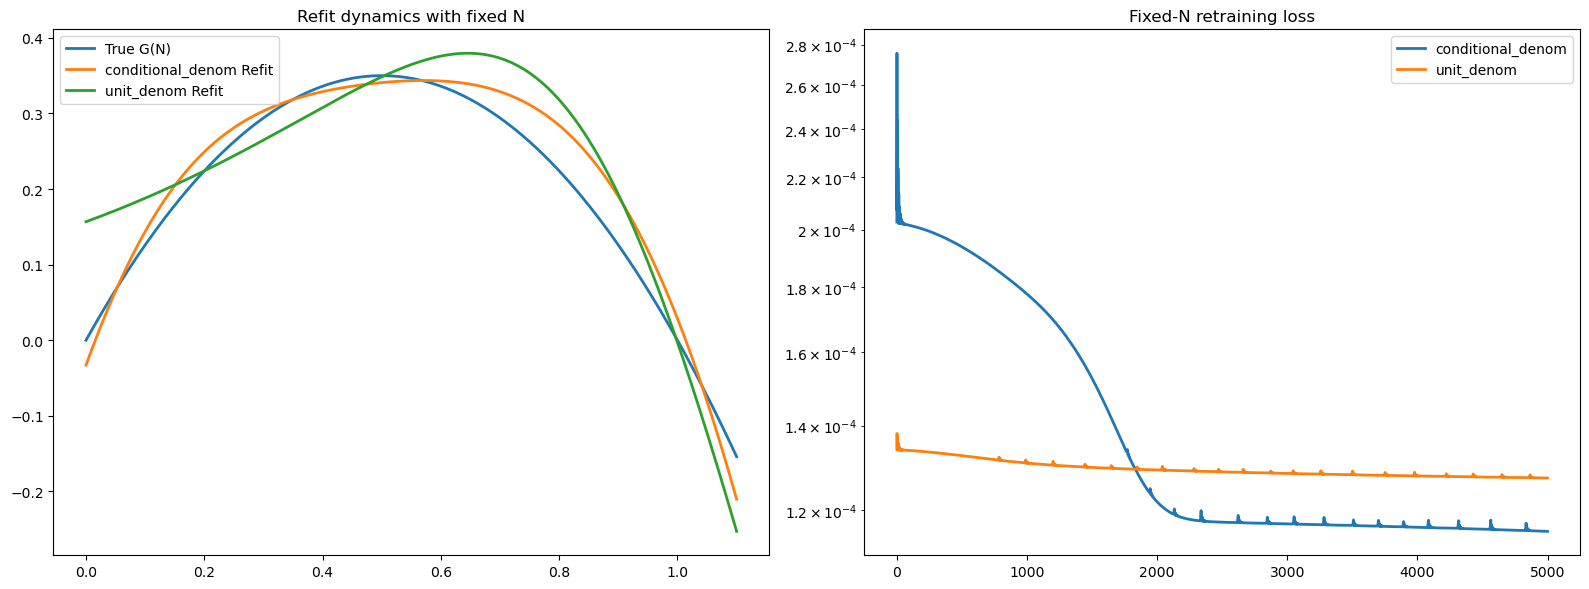

In [63]:
# ============================================================
# 15. Post-processing: Retrain only G-net with fixed N
# ============================================================
def build_fixed_solution_targets(sol_net, t_phys):
    sol_net_eval = copy.deepcopy(sol_net).to(device)
    sol_net_eval.train() # Set to train just to be safe

    # 1. Force network parameters to require grad 
    # (prevents autograd from culling the graph during derivative calculation)
    for p in sol_net_eval.parameters():
        p.requires_grad_(True)

    # 2. Force enable gradients context
    with torch.enable_grad():
        t_req = t_phys.clone().detach().requires_grad_(True)
        N_phys = sol_net_eval(t_req)
        
        dN_dt = torch.autograd.grad(
            outputs=N_phys,
            inputs=t_req,
            grad_outputs=torch.ones_like(N_phys),
            create_graph=False,
            retain_graph=False,
        )[0]

    return N_phys.detach(), dN_dt.detach()

def retrain_dynamics_with_fixed_solution(sol_net_fixed, dyn_net_init, t_phys, lr=1e-3, epochs=5000):
    dyn_net = copy.deepcopy(dyn_net_init).to(device)
    dyn_net.train()

    # 3. Explicitly ensure the G-network parameters require gradients!
    # If they are accidentally frozen from earlier evaluations, loss.backward() crashes here.
    for p in dyn_net.parameters():
        p.requires_grad_(True)

    N_fixed, dN_dt_fixed = build_fixed_solution_targets(sol_net_fixed, t_phys)
    
    opt = torch.optim.Adam(dyn_net.parameters(), lr=lr)
    history, best_loss = [], float("inf")
    best_state = copy.deepcopy(dyn_net.state_dict())

    # 4. Wrap the entire backward pass loop in enable_grad
    with torch.enable_grad():
        for ep in range(epochs):
            opt.zero_grad()
            
            G_pred = dyn_net(N_fixed)
            loss = 0.5 * torch.mean((dN_dt_fixed - G_pred) ** 2)
            
            loss.backward()
            opt.step()

            loss_val = loss.item()
            history.append(loss_val)

            if loss_val < best_loss:
                best_loss = loss_val
                best_state = copy.deepcopy(dyn_net.state_dict())

            if ep % 1000 == 0:
                print(f"   [G-Refit] ep={ep:5d} | PDE Loss={loss_val:.6e}", end="\r")

    print(f"   [G-Refit] ep={epochs:5d} | PDE Loss={history[-1]:.6e}    ")
    dyn_net.load_state_dict(best_state)
    dyn_net.eval()
    return dyn_net, history, best_loss


# Execution
refit_results = {}
refit_epochs = 5000  # Set to actual retraining length
refit_lr = 1e-3

for model_name, model_result in results.items():
    print(f"\nRefitting G with fixed N for model: {model_name}")
    refit_dynamics, refit_histories, refit_metrics = [], [], []

    pairs = list(zip(model_result["ensemble_solutions"], model_result["ensemble_dynamics"]))
    
    for k, (sol_net, dyn_net) in enumerate(pairs):
        try:
            dyn_refit, hist, best_phys = retrain_dynamics_with_fixed_solution(sol_net, dyn_net, t_phys, lr=refit_lr, epochs=refit_epochs)
            
            with torch.no_grad():
                G_pred = dyn_refit(N_grid).squeeze(-1)
                G_rel_l2 = (torch.norm(G_pred - G_exact) / (torch.norm(G_exact) + 1e-12)).item()

            refit_dynamics.append(dyn_refit)
            refit_histories.append(hist)
            refit_metrics.append({"G_rel_l2_refit": G_rel_l2, "final_fixed_phys": hist[-1]})
            print(f"   Member {k} | G Rel L2: {G_rel_l2:.6e}")
            
        except Exception as e:
            # Added traceback to see EXACTLY what line breaks if it happens again
            import traceback
            print(f"   Member {k} | Skipped due to error: {e}")
            traceback.print_exc()

    if refit_dynamics:
        refit_results[model_name] = {
            "ensemble_dynamics_refit": refit_dynamics, 
            "refit_histories": refit_histories, 
            "refit_metrics": refit_metrics
        }


# ============================================================
# 16. Post-Refit Summaries and Plotting
# ============================================================
refit_summaries = {}
for name, res in refit_results.items():
    with torch.no_grad():
        G_ens = torch.stack([d(N_grid).squeeze(-1) for d in res["ensemble_dynamics_refit"]], dim=0)
        G_mean = G_ens.mean(dim=0)
        G_std = G_ens.std(dim=0) if G_ens.shape[0] > 1 else torch.zeros_like(G_mean)
        refit_summaries[name] = {"G_mean": G_mean, "G_std": G_std, "G_rel_l2": (torch.norm(G_mean - G_exact) / (torch.norm(G_exact) + 1e-12)).item()}

print("\n\n================ FIXED-N / G-ONLY REFINEMENT SUMMARY ================")
for name in model_configs:
    if name in refit_summaries:
        print(f"Model: {name}\n  Before: G rel L2 = {summaries[name]['rel_l2_G']:.6e}\n  After : G rel L2 = {refit_summaries[name]['G_rel_l2']:.6e}")
    else:
        print(f"Model: {name}\n  No refit summary available")
print("====================================================================")


fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Refit Dynamics Plot
axes[0].plot(N_grid.cpu(), G_exact.cpu(), lw=2, label="True G(N)")
for name, s in refit_summaries.items():
    axes[0].plot(N_grid.cpu(), s["G_mean"].cpu(), lw=2, label=f"{name} Refit")
    axes[0].fill_between(N_grid.squeeze(-1).cpu().numpy(), (s["G_mean"] - 2*s["G_std"]).cpu().numpy(), (s["G_mean"] + 2*s["G_std"]).cpu().numpy(), alpha=0.20)
axes[0].set_title("Refit dynamics with fixed N")
if axes[0].get_legend_handles_labels()[0]: axes[0].legend()

# Refit Training Loss
for name, res in refit_results.items():
    if res["refit_histories"]:
        arr = np.array(res["refit_histories"])
        axes[1].plot(np.mean(arr, axis=0), lw=2, label=name)
        axes[1].fill_between(np.arange(arr.shape[1]), np.mean(arr, axis=0) - np.std(arr, axis=0), np.mean(arr, axis=0) + np.std(arr, axis=0), alpha=0.15)
axes[1].set_yscale("log")
axes[1].set_title("Fixed-N retraining loss")
if axes[1].get_legend_handles_labels()[0]: axes[1].legend()

plt.tight_layout()
plt.show()

Split  1/1 done | PINN-init sel = 2.136650e-03 | UDE best sel = 1.987482e-03 | UDE best epoch = 19988 | PINN IC target = 0.092332 | UDE best y0 = 0.090949 | y0 true = 0.100000

PINN initialization summary across splits
-----------------------------------------
Mean PINN best selection loss: 2.136650e-03
Std  PINN best selection loss: 0.000000e+00
Mean PINN best epoch: 9999.00
Std  PINN best epoch: 0.00
Mean UDE init y0 from PINN: 0.092332
Std  UDE init y0 from PINN: 0.000000

UDE summary across splits
------------------------
Mean UDE best selection loss: 1.987482e-03
Std  UDE best selection loss: 0.000000e+00
Mean UDE best epoch: 19988.00
Std  UDE best epoch: 0.00
Mean learned UDE y0: 0.090949
Std  learned UDE y0: 0.000000

Per-split initialization and UDE results:
Split  1 | PINN best sel = 2.136650e-03 @ 9999 | PINN IC = 0.092332 | UDE best sel = 1.987482e-03 @ 19988 | final UDE y0 = 0.090949


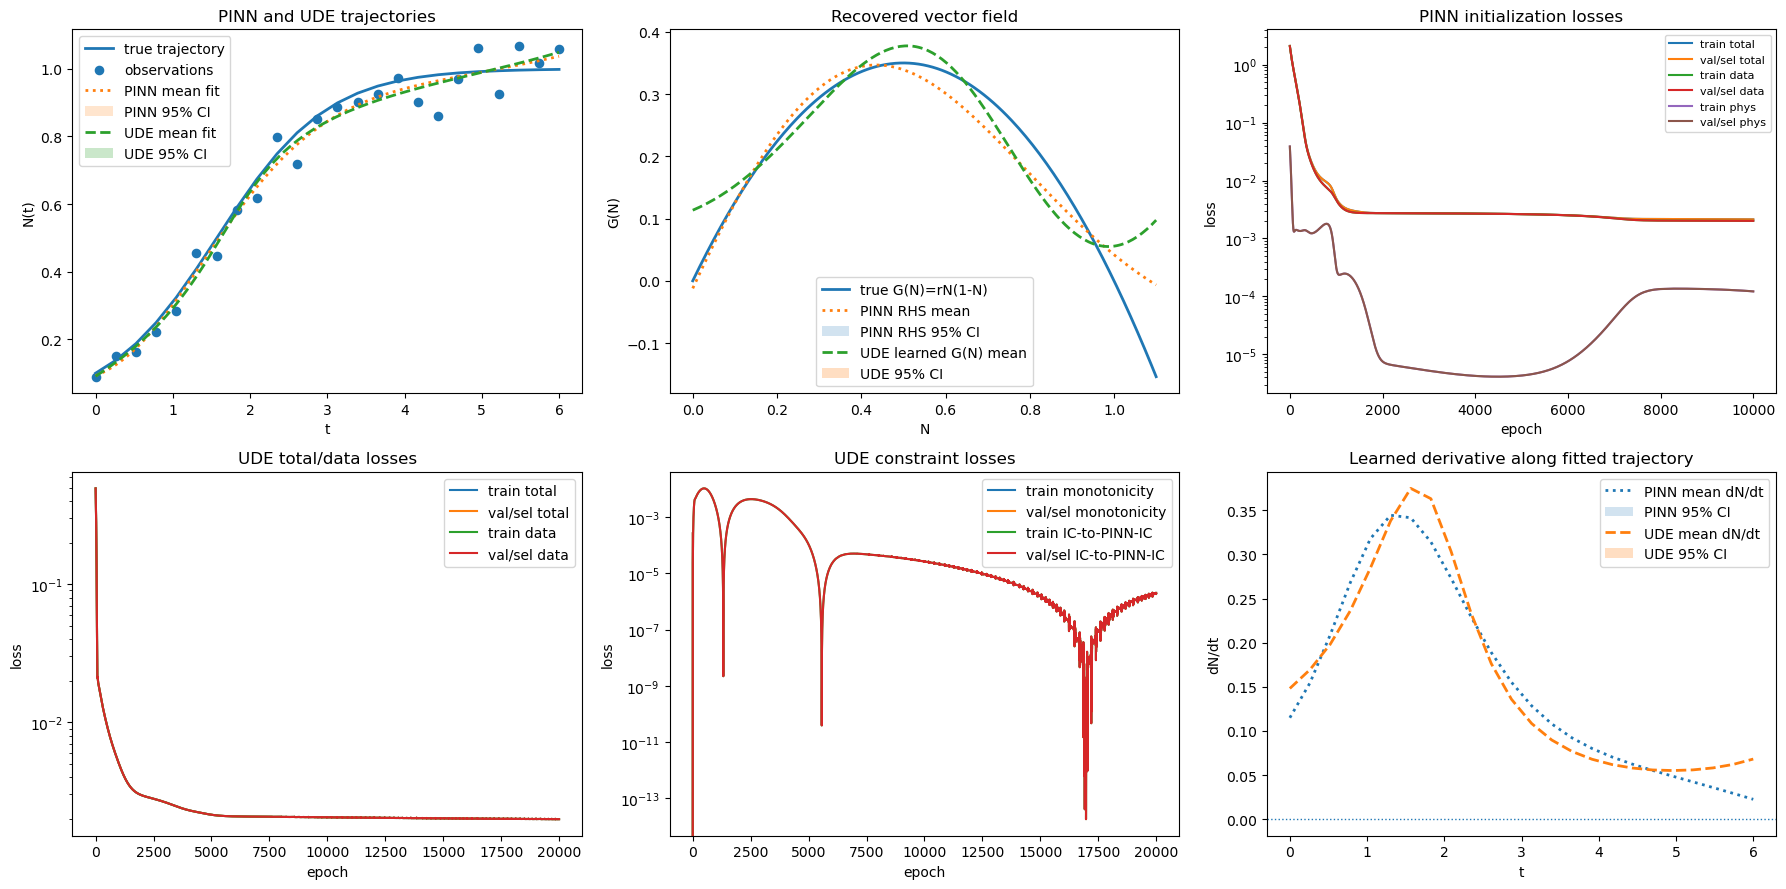

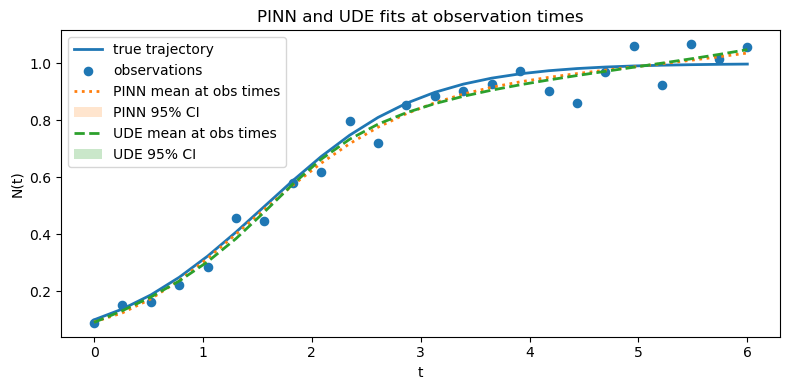


Observed time points: mean prediction and 95% CI across split-best models
t =  0.000 | true N(t) =  0.100000 | data =  0.089592 | PINN mean fit =  0.092332 | PINN 95% CI = [ 0.092332,  0.092332] | UDE mean fit =  0.090949 | UDE 95% CI = [ 0.090949,  0.090949] | PINN mean dN/dt =  0.114917 | PINN dN/dt CI = [ 0.114917,  0.114917] | UDE mean dN/dt =  0.148137 | UDE dN/dt CI = [ 0.148137,  0.148137]
t =  0.261 | true N(t) =  0.137997 | data =  0.150645 | PINN mean fit =  0.124594 | PINN 95% CI = [ 0.124594,  0.124594] | UDE mean fit =  0.132240 | UDE 95% CI = [ 0.132240,  0.132240] | PINN mean dN/dt =  0.154470 | PINN dN/dt CI = [ 0.154470,  0.154470] | UDE mean dN/dt =  0.169473 | UDE dN/dt CI = [ 0.169473,  0.169473]
t =  0.522 | true N(t) =  0.187425 | data =  0.162981 | PINN mean fit =  0.173529 | PINN 95% CI = [ 0.173529,  0.173529] | UDE mean fit =  0.180001 | UDE 95% CI = [ 0.180001,  0.180001] | PINN mean dN/dt =  0.208635 | PINN dN/dt CI = [ 0.208635,  0.208635] | UDE mean dN/dt

In [1]:
import copy
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# ----------------------------
# Reproducibility
# ----------------------------
torch.manual_seed(0)
np.random.seed(0)

device = torch.device("cpu")


# ============================================================
# 1. Ground-truth system: logistic growth dN/dt = r N (1 - N)
#    NOTE:
#    - N0_true is used ONLY to generate synthetic data.
#    - It is NOT used in any training/validation loss.
# ============================================================
r_true = 1.4
N0_true = 0.1
numpts = 4 * (24 // 4)

t_obs = torch.linspace(0.0, 6.0, numpts, device=device)  # (T,)
t_obs_col = t_obs.view(-1, 1)                            # (T,1)

def G_true(N):
    return r_true * N * (1.0 - N)


# ============================================================
# 2. Differentiable RK4 ODE solver
# ============================================================
def rk4_step(f, y, t, dt):
    k1 = f(t, y)
    k2 = f(t + 0.5 * dt, y + 0.5 * dt * k1)
    k3 = f(t + 0.5 * dt, y + 0.5 * dt * k2)
    k4 = f(t + dt, y + dt * k3)
    return y + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)

def odeint_rk4(f, y0, t):
    """
    Integrate y' = f(t,y) over time grid t using RK4.
    y0 shape: (batch, dim) or (dim,)
    returns: tensor of shape (len(t), ...) matching y0
    """
    ys = [y0]
    y = y0
    for i in range(len(t) - 1):
        ti = t[i]
        dt = t[i + 1] - t[i]
        y = rk4_step(f, y, ti, dt)
        ys.append(y)
    return torch.stack(ys, dim=0)


# ============================================================
# 3. Simulate observed data
# ============================================================
with torch.no_grad():
    y0_true = torch.tensor([[N0_true]], dtype=torch.float32, device=device)
    y_true = odeint_rk4(lambda t, y: G_true(y), y0_true, t_obs).squeeze(1)  # (T,1)

noise_std = 0.05
torch.manual_seed(2)
y_data = y_true + 0.1 * torch.randn_like(y_true) * y_true


# ============================================================
# 4. PINN pretraining models
#    We use these to initialize the UDE.
# ============================================================
class SolutionNet(nn.Module):
    def __init__(self, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 1),
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.net.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight, gain=0.8)
                nn.init.zeros_(m.bias)

    def forward(self, t):
        return self.net(t)


class DynamicsNet(nn.Module):
    def __init__(self, hidden_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 1),
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.net.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight, gain=0.8)
                nn.init.zeros_(m.bias)

    def forward(self, N):
        return self.net(N)


# ============================================================
# 5. UDE model
#    Same architecture as DynamicsNet so weights can be copied
# ============================================================
class ODEFunc(nn.Module):
    def __init__(self, hidden_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 1),
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.net.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight, gain=0.8)
                nn.init.zeros_(m.bias)

    def forward(self, t, y):
        return self.net(y)


# ============================================================
# 6. Helpers
# ============================================================
def mean_and_ci(arr, ci=1.96):
    """
    arr shape: (n_runs, n_points)
    returns mean, lower, upper
    """
    arr = np.asarray(arr)
    mean = arr.mean(axis=0)
    if arr.shape[0] == 1:
        lower = mean.copy()
        upper = mean.copy()
    else:
        sem = arr.std(axis=0, ddof=1) / np.sqrt(arr.shape[0])
        lower = mean - ci * sem
        upper = mean + ci * sem
    return mean, lower, upper

def safe_mse(pred, target, device=None):
    if pred.numel() == 0:
        if device is None:
            device = pred.device
        return torch.tensor(0.0, device=device)
    return torch.mean((pred - target) ** 2)

def safe_std(arr):
    arr = np.asarray(arr)
    if arr.size <= 1:
        return 0.0
    return arr.std(ddof=1)

def compute_pinn_time_derivative(sol_net, t):
    """
    t shape: (n,1), requires_grad=True
    returns:
      N_pred: shape (n,1)
      dN_dt:  shape (n,1)
    """
    N_pred = sol_net(t)
    dN_dt = torch.autograd.grad(
        outputs=N_pred,
        inputs=t,
        grad_outputs=torch.ones_like(N_pred),
        create_graph=True,
        retain_graph=True,
    )[0]
    return N_pred, dN_dt


# ============================================================
# 7. Settings
# ============================================================
n_splits = 1
val_fraction = 0.0

n_obs = t_obs.shape[0]
n_val = int(round(val_fraction * n_obs))
n_train = n_obs - n_val
has_val = n_val > 0

# ---- PINN pretraining settings (used only for initialization)
pinn_n_epochs = 10000
pinn_n_col = 1000
t_col_base = torch.linspace(0.0, 6.0, pinn_n_col, device=device).view(-1, 1)

lambda_phys_pinn = 1.0
lambda_ic_pinn = 0.0     # no true IC in losses
lambda_mon_pinn = 0.0
pinn_learning_rate = 1e-3
hidden_dim_sol = 4
hidden_dim_dyn = 4

# ---- UDE training settings
ude_n_epochs = 20000
lambda_mon_ude = 1.0
lambda_reg_ude = 0.0     # regularization intentionally not used
lambda_ic_ude = 1.0
ude_learning_rate = 1e-3
hidden_dim_ude = 4

# evaluation grids
t_plot = torch.linspace(0.0, 6.0, 200, device=device)
t_plot_col = t_plot.view(-1, 1)
N_grid = torch.linspace(0, 1.1, 200, device=device).view(-1, 1)

# ============================================================
# 8. Containers across splits
# ============================================================
# PINN-pretraining histories
pinn_train_total_histories = []
pinn_train_data_histories = []
pinn_train_phys_histories = []
pinn_train_ic_histories = []
pinn_train_mon_histories = []

pinn_val_total_histories = []
pinn_val_data_histories = []
pinn_val_phys_histories = []
pinn_val_ic_histories = []
pinn_val_mon_histories = []

pinn_init_y0s = []
pinn_best_val_losses = []
pinn_best_epochs = []
pinn_rhs_histories = []
pinn_traj_histories = []
pinn_obs_fit_histories = []
pinn_rhs_fit_histories = []

# UDE histories
ude_train_total_histories = []
ude_train_data_histories = []
ude_train_mon_histories = []
ude_train_ic_histories = []
ude_train_reg_histories = []

ude_val_total_histories = []
ude_val_data_histories = []
ude_val_mon_histories = []
ude_val_ic_histories = []
ude_val_reg_histories = []

# predictions
traj_histories = []
rhs_histories = []
obs_fit_histories = []
rhs_fit_histories = []

# model-selection summaries
ude_best_val_losses = []
ude_best_epochs = []
ude_best_y0_values = []

train_indices_all = []
val_indices_all = []


# ============================================================
# 9. Loop over splits
#    For each split:
#      (A) PINN pretraining of dyn_net + sol_net
#      (B) Use pretrained dyn_net + sol_net(0) to initialize UDE
#      (C) Train UDE and keep best validation model
#
#    IMPORTANT:
#    - No true IC is used anywhere in the losses.
#    - The PINN-estimated IC is used as the UDE initialization target.
# ============================================================
for split in range(n_splits):
    # -------------------------
    # Split
    # -------------------------
    g = torch.Generator(device=device)
    g.manual_seed(1000 + split)

    perm = torch.randperm(n_obs, generator=g, device=device)
    train_idx = perm[:n_train].sort().values
    val_idx = perm[n_train:].sort().values

    train_indices_all.append(train_idx.cpu().numpy())
    val_indices_all.append(val_idx.cpu().numpy())

    t_train = t_obs[train_idx]
    y_train = y_data[train_idx]

    if has_val:
        t_val = t_obs[val_idx]
        y_val = y_data[val_idx]
    else:
        t_val = torch.empty(0, device=device)
        y_val = torch.empty((0, y_data.shape[1]), device=device)

    # ========================================================
    # 9A. PINN pretraining
    # ========================================================
    torch.manual_seed(1234 + split)
    np.random.seed(1234 + split)

    sol_net = SolutionNet(hidden_dim=hidden_dim_sol).to(device)
    dyn_net = DynamicsNet(hidden_dim=hidden_dim_dyn).to(device)

    pinn_optimizer = torch.optim.Adam(
        list(sol_net.parameters()) + list(dyn_net.parameters()),
        lr=pinn_learning_rate
    )

    pinn_train_total_history = []
    pinn_train_data_history = []
    pinn_train_phys_history = []
    pinn_train_ic_history = []
    pinn_train_mon_history = []

    pinn_val_total_history = []
    pinn_val_data_history = []
    pinn_val_phys_history = []
    pinn_val_ic_history = []
    pinn_val_mon_history = []

    pinn_best_val_loss = float("inf")
    pinn_best_epoch = -1
    pinn_best_state = None

    for epoch in range(pinn_n_epochs):
        pinn_optimizer.zero_grad()

        # Train data loss
        N_pred_train = sol_net(t_train.view(-1, 1))
        train_data_loss = torch.mean((N_pred_train - y_train) ** 2)

        # IC loss placeholder: intentionally not used
        ic_loss = torch.tensor(0.0, device=device)

        # Physics + monotonicity
        t_col = t_col_base.clone().detach().requires_grad_(True)
        N_pred_col = sol_net(t_col)

        dN_dt = torch.autograd.grad(
            outputs=N_pred_col,
            inputs=t_col,
            grad_outputs=torch.ones_like(N_pred_col),
            create_graph=True,
            retain_graph=True,
        )[0]

        rhs_pred = dyn_net(N_pred_col)
        phys_res = dN_dt - rhs_pred
        phys_loss = torch.mean(phys_res ** 2)

        mon_violation = torch.relu(-dN_dt)
        mon_loss = torch.sum(mon_violation ** 2)

        train_loss = (
            train_data_loss
            + lambda_phys_pinn * phys_loss
            # + lambda_ic_pinn * ic_loss
            + lambda_mon_pinn * mon_loss
        )

        train_loss.backward()
        pinn_optimizer.step()

        # Validation losses (or reuse train loss if validation is disabled)
        if has_val:
            with torch.no_grad():
                N_pred_val = sol_net(t_val.view(-1, 1))
                val_data_loss = safe_mse(N_pred_val, y_val, device=device)
                val_ic_loss = torch.tensor(0.0, device=device)

            t_col_val = t_col_base.clone().detach().requires_grad_(True)
            N_pred_col_val = sol_net(t_col_val)

            dN_dt_val = torch.autograd.grad(
                outputs=N_pred_col_val,
                inputs=t_col_val,
                grad_outputs=torch.ones_like(N_pred_col_val),
                create_graph=False,
                retain_graph=False,
            )[0]

            rhs_pred_val = dyn_net(N_pred_col_val)
            val_phys_res = dN_dt_val - rhs_pred_val
            val_phys_loss = torch.mean(val_phys_res ** 2)

            val_mon_violation = torch.relu(-dN_dt_val)
            val_mon_loss = torch.sum(val_mon_violation ** 2)

            val_loss = (
                val_data_loss
                + lambda_phys_pinn * val_phys_loss
                # + lambda_ic_pinn * val_ic_loss
                + lambda_mon_pinn * val_mon_loss
            )

            pinn_selection_loss = val_loss
        else:
            val_data_loss = train_data_loss.detach()
            val_phys_loss = phys_loss.detach()
            val_mon_loss = mon_loss.detach()
            val_ic_loss = ic_loss.detach()
            val_loss = train_loss.detach()

            # no validation set -> select using training loss
            pinn_selection_loss = train_loss.detach()

        pinn_train_total_history.append(train_loss.item())
        pinn_train_data_history.append(train_data_loss.item())
        pinn_train_phys_history.append(phys_loss.item())
        pinn_train_ic_history.append(ic_loss.item())
        pinn_train_mon_history.append(mon_loss.item())

        pinn_val_total_history.append(val_loss.item())
        pinn_val_data_history.append(val_data_loss.item())
        pinn_val_phys_history.append(val_phys_loss.item())
        pinn_val_ic_history.append(val_ic_loss.item())
        pinn_val_mon_history.append(val_mon_loss.item())

        if pinn_selection_loss.item() < pinn_best_val_loss:
            pinn_best_val_loss = pinn_selection_loss.item()
            pinn_best_epoch = epoch
            pinn_best_state = {
                "sol_net": copy.deepcopy(sol_net.state_dict()),
                "dyn_net": copy.deepcopy(dyn_net.state_dict()),
            }

        if epoch % 1000 == 0:
            print(
                f"Split {split + 1:2d}/{n_splits} | "
                f"[PINN init] Epoch {epoch:5d} | "
                f"TrainTot {train_loss.item():.6e} | "
                f"{'ValTot' if has_val else 'SelTot'} {pinn_selection_loss.item():.6e}",
                end="\r",
            )

    if pinn_best_state is None:
        pinn_best_state = {
            "sol_net": copy.deepcopy(sol_net.state_dict()),
            "dyn_net": copy.deepcopy(dyn_net.state_dict()),
        }
        pinn_best_val_loss = train_loss.item()
        pinn_best_epoch = pinn_n_epochs - 1

    sol_net.load_state_dict(pinn_best_state["sol_net"])
    dyn_net.load_state_dict(pinn_best_state["dyn_net"])

    with torch.no_grad():
        # PINN-estimated IC used to initialize the UDE
        y0_init_from_pinn = sol_net(torch.zeros((1, 1), device=device)).detach().clone()

        # PINN trajectory / RHS on evaluation grids
        pinn_y_plot = sol_net(t_plot_col)
        pinn_y_obs = sol_net(t_obs_col)
        pinn_G_grid = dyn_net(N_grid)
        pinn_rhs_fit = dyn_net(pinn_y_obs)

    pinn_init_y0s.append(y0_init_from_pinn.item())
    pinn_best_val_losses.append(pinn_best_val_loss)
    pinn_best_epochs.append(pinn_best_epoch)

    pinn_train_total_histories.append(pinn_train_total_history)
    pinn_train_data_histories.append(pinn_train_data_history)
    pinn_train_phys_histories.append(pinn_train_phys_history)
    pinn_train_ic_histories.append(pinn_train_ic_history)
    pinn_train_mon_histories.append(pinn_train_mon_history)

    pinn_val_total_histories.append(pinn_val_total_history)
    pinn_val_data_histories.append(pinn_val_data_history)
    pinn_val_phys_histories.append(pinn_val_phys_history)
    pinn_val_ic_histories.append(pinn_val_ic_history)
    pinn_val_mon_histories.append(pinn_val_mon_history)

    pinn_rhs_histories.append(pinn_G_grid.squeeze(1).cpu().numpy())
    pinn_traj_histories.append(pinn_y_plot.squeeze(1).cpu().numpy())
    pinn_obs_fit_histories.append(pinn_y_obs.squeeze(1).cpu().numpy())
    pinn_rhs_fit_histories.append(pinn_rhs_fit.squeeze(1).cpu().numpy())

    # ========================================================
    # 9B. Initialize UDE from pretrained PINN dynamics
    # ========================================================
    func = ODEFunc(hidden_dim=hidden_dim_ude).to(device)

    # copy dynamics weights
    #func.net.load_state_dict(copy.deepcopy(dyn_net.net.state_dict()))

    # initialize UDE IC from PINN IC
    y0_est = nn.Parameter(y0_init_from_pinn.clone())

    # use PINN IC as the UDE "true" IC target in losses
    y0_target_for_ude = y0_init_from_pinn.detach().clone()

    ude_params = list(func.parameters()) + [y0_est]
    ude_optimizer = torch.optim.Adam(ude_params, lr=ude_learning_rate)

    ude_train_total_history = []
    ude_train_data_history = []
    ude_train_mon_history = []
    ude_train_ic_history = []
    ude_train_reg_history = []

    ude_val_total_history = []
    ude_val_data_history = []
    ude_val_mon_history = []
    ude_val_ic_history = []
    ude_val_reg_history = []

    ude_best_val_loss = float("inf")
    ude_best_epoch = -1
    ude_best_state = None

    # ========================================================
    # 9C. Train UDE
    # ========================================================
    for epoch in range(ude_n_epochs):
        ude_optimizer.zero_grad()

        # Predict full trajectory, then slice
        y_pred_full = odeint_rk4(func, y0_est, t_obs).squeeze(1)  # (T,1)
        y_pred_train = y_pred_full[train_idx]

        # Train data loss
        train_data_loss = torch.mean((y_pred_train - y_train) ** 2)

        # Monotonicity on train points
        rhs_train = func(t_train.view(-1, 1), y_pred_train)
        train_mon_violation = torch.relu(-rhs_train)
        train_mon_loss = torch.sum(train_mon_violation ** 2)

        # IC loss: target is the PINN-estimated IC, not the true IC
        train_ic_loss = torch.mean((y0_est - y0_target_for_ude) ** 2)

        # Reg loss placeholder: intentionally not used / commented out
        reg_loss = torch.tensor(0.0, device=device)

        train_loss = (
            train_data_loss
            # + lambda_mon_ude * train_mon_loss
            # + lambda_reg_ude * reg_loss
            #+ lambda_ic_ude * train_ic_loss
        )

        train_loss.backward()
        ude_optimizer.step()

        # Validation (or reuse training metrics if validation is disabled)
        with torch.no_grad():
            y_pred_full_val = odeint_rk4(func, y0_est, t_obs).squeeze(1)

            if has_val:
                y_pred_val = y_pred_full_val[val_idx]
                val_data_loss = safe_mse(y_pred_val, y_val, device=device)

                rhs_val = func(t_val.view(-1, 1), y_pred_val)
                val_mon_violation = torch.relu(-rhs_val)
                val_mon_loss = torch.sum(val_mon_violation ** 2)

                val_ic_loss = torch.mean((y0_est - y0_target_for_ude) ** 2)
                val_reg_loss = torch.tensor(0.0, device=device)

                val_loss = (
                    val_data_loss
                    # + lambda_mon_ude * val_mon_loss
                    # + lambda_reg_ude * val_reg_loss
                    #+ lambda_ic_ude * val_ic_loss
                )

                ude_selection_loss = val_loss
            else:
                val_data_loss = train_data_loss.detach()
                val_mon_loss = train_mon_loss.detach()
                val_ic_loss = train_ic_loss.detach()
                val_reg_loss = reg_loss.detach()
                val_loss = train_loss.detach()

                # no validation set -> select using training loss
                ude_selection_loss = train_loss.detach()

        ude_train_total_history.append(train_loss.item())
        ude_train_data_history.append(train_data_loss.item())
        ude_train_mon_history.append(train_mon_loss.item())
        ude_train_ic_history.append(train_ic_loss.item())
        ude_train_reg_history.append((lambda_reg_ude * reg_loss).item())

        ude_val_total_history.append(val_loss.item())
        ude_val_data_history.append(val_data_loss.item())
        ude_val_mon_history.append(val_mon_loss.item())
        ude_val_ic_history.append(val_ic_loss.item())
        ude_val_reg_history.append((lambda_reg_ude * val_reg_loss).item())

        if ude_selection_loss.item() < ude_best_val_loss:
            ude_best_val_loss = ude_selection_loss.item()
            ude_best_epoch = epoch
            ude_best_state = {
                "func": copy.deepcopy(func.state_dict()),
                "y0_est": y0_est.detach().clone(),
                "y0_target_for_ude": y0_target_for_ude.detach().clone(),
            }

        if epoch % 1000 == 0:
            print(
                f"Split {split + 1:2d}/{n_splits} | "
                f"[UDE] Epoch {epoch:5d} | "
                f"TrainTot {train_loss.item():.6e} | "
                f"{'ValTot' if has_val else 'SelTot'} {ude_selection_loss.item():.6e}",
                end="\r",
            )

    if ude_best_state is None:
        ude_best_state = {
            "func": copy.deepcopy(func.state_dict()),
            "y0_est": y0_est.detach().clone(),
            "y0_target_for_ude": y0_target_for_ude.detach().clone(),
        }
        ude_best_val_loss = train_loss.item()
        ude_best_epoch = ude_n_epochs - 1

    print(
        f"Split {split + 1:2d}/{n_splits} done | "
        f"PINN-init {'val' if has_val else 'sel'} = {pinn_best_val_loss:.6e} | "
        f"UDE best {'val' if has_val else 'sel'} = {ude_best_val_loss:.6e} | "
        f"UDE best epoch = {ude_best_epoch:5d} | "
        f"PINN IC target = {y0_target_for_ude.item():.6f} | "
        f"UDE best y0 = {ude_best_state['y0_est'].item():.6f} | "
        f"y0 true = {y0_true.item():.6f}"
    )

    # restore best UDE
    func.load_state_dict(ude_best_state["func"])
    y0_est = nn.Parameter(ude_best_state["y0_est"].clone())
    y0_target_for_ude = ude_best_state["y0_target_for_ude"].clone()

    # evaluate best UDE
    with torch.no_grad():
        y_fit_plot = odeint_rk4(func, y0_est, t_plot).squeeze(1)
        y_fit_obs = odeint_rk4(func, y0_est, t_obs).squeeze(1)

        G_grid_learned = func(torch.tensor(0.0, device=device), N_grid)
        rhs_fit = func(t_obs_col, y_fit_obs)

    ude_train_total_histories.append(ude_train_total_history)
    ude_train_data_histories.append(ude_train_data_history)
    ude_train_mon_histories.append(ude_train_mon_history)
    ude_train_ic_histories.append(ude_train_ic_history)
    ude_train_reg_histories.append(ude_train_reg_history)

    ude_val_total_histories.append(ude_val_total_history)
    ude_val_data_histories.append(ude_val_data_history)
    ude_val_mon_histories.append(ude_val_mon_history)
    ude_val_ic_histories.append(ude_val_ic_history)
    ude_val_reg_histories.append(ude_val_reg_history)

    traj_histories.append(y_fit_plot.squeeze(1).cpu().numpy())
    rhs_histories.append(G_grid_learned.squeeze(1).cpu().numpy())
    obs_fit_histories.append(y_fit_obs.squeeze(1).cpu().numpy())
    rhs_fit_histories.append(rhs_fit.squeeze(1).cpu().numpy())

    ude_best_val_losses.append(ude_best_val_loss)
    ude_best_epochs.append(ude_best_epoch)
    ude_best_y0_values.append(ude_best_state["y0_est"].item())


# ============================================================
# 10. Aggregate across splits
# ============================================================
# PINN init
pinn_train_total_histories = np.array(pinn_train_total_histories)
pinn_train_data_histories = np.array(pinn_train_data_histories)
pinn_train_phys_histories = np.array(pinn_train_phys_histories)
pinn_train_ic_histories = np.array(pinn_train_ic_histories)
pinn_train_mon_histories = np.array(pinn_train_mon_histories)

pinn_val_total_histories = np.array(pinn_val_total_histories)
pinn_val_data_histories = np.array(pinn_val_data_histories)
pinn_val_phys_histories = np.array(pinn_val_phys_histories)
pinn_val_ic_histories = np.array(pinn_val_ic_histories)
pinn_val_mon_histories = np.array(pinn_val_mon_histories)

pinn_best_val_losses = np.array(pinn_best_val_losses)
pinn_best_epochs = np.array(pinn_best_epochs)
pinn_init_y0s = np.array(pinn_init_y0s)
pinn_rhs_histories = np.array(pinn_rhs_histories)
pinn_traj_histories = np.array(pinn_traj_histories)
pinn_obs_fit_histories = np.array(pinn_obs_fit_histories)
pinn_rhs_fit_histories = np.array(pinn_rhs_fit_histories)

# UDE
ude_train_total_histories = np.array(ude_train_total_histories)
ude_train_data_histories = np.array(ude_train_data_histories)
ude_train_mon_histories = np.array(ude_train_mon_histories)
ude_train_ic_histories = np.array(ude_train_ic_histories)
ude_train_reg_histories = np.array(ude_train_reg_histories)

ude_val_total_histories = np.array(ude_val_total_histories)
ude_val_data_histories = np.array(ude_val_data_histories)
ude_val_mon_histories = np.array(ude_val_mon_histories)
ude_val_ic_histories = np.array(ude_val_ic_histories)
ude_val_reg_histories = np.array(ude_val_reg_histories)

traj_histories = np.array(traj_histories)
rhs_histories = np.array(rhs_histories)
obs_fit_histories = np.array(obs_fit_histories)
rhs_fit_histories = np.array(rhs_fit_histories)

ude_best_val_losses = np.array(ude_best_val_losses)
ude_best_epochs = np.array(ude_best_epochs)
ude_best_y0_values = np.array(ude_best_y0_values)

# PINN stats
pinn_train_total_mean, pinn_train_total_lo, pinn_train_total_hi = mean_and_ci(pinn_train_total_histories)
pinn_train_data_mean, pinn_train_data_lo, pinn_train_data_hi = mean_and_ci(pinn_train_data_histories)
pinn_train_phys_mean, pinn_train_phys_lo, pinn_train_phys_hi = mean_and_ci(pinn_train_phys_histories)

pinn_val_total_mean, pinn_val_total_lo, pinn_val_total_hi = mean_and_ci(pinn_val_total_histories)
pinn_val_data_mean, pinn_val_data_lo, pinn_val_data_hi = mean_and_ci(pinn_val_data_histories)
pinn_val_phys_mean, pinn_val_phys_lo, pinn_val_phys_hi = mean_and_ci(pinn_val_phys_histories)

# UDE stats
ude_train_total_mean, ude_train_total_lo, ude_train_total_hi = mean_and_ci(ude_train_total_histories)
ude_train_data_mean, ude_train_data_lo, ude_train_data_hi = mean_and_ci(ude_train_data_histories)
ude_train_mon_mean, ude_train_mon_lo, ude_train_mon_hi = mean_and_ci(ude_train_mon_histories)
ude_train_ic_mean, ude_train_ic_lo, ude_train_ic_hi = mean_and_ci(ude_train_ic_histories)

ude_val_total_mean, ude_val_total_lo, ude_val_total_hi = mean_and_ci(ude_val_total_histories)
ude_val_data_mean, ude_val_data_lo, ude_val_data_hi = mean_and_ci(ude_val_data_histories)
ude_val_mon_mean, ude_val_mon_lo, ude_val_mon_hi = mean_and_ci(ude_val_mon_histories)
ude_val_ic_mean, ude_val_ic_lo, ude_val_ic_hi = mean_and_ci(ude_val_ic_histories)

traj_mean, traj_lo, traj_hi = mean_and_ci(traj_histories)
rhs_mean, rhs_lo, rhs_hi = mean_and_ci(rhs_histories)
obs_fit_mean, obs_fit_lo, obs_fit_hi = mean_and_ci(obs_fit_histories)
rhs_fit_mean, rhs_fit_lo, rhs_fit_hi = mean_and_ci(rhs_fit_histories)

pinn_traj_mean, pinn_traj_lo, pinn_traj_hi = mean_and_ci(pinn_traj_histories)
pinn_rhs_mean, pinn_rhs_lo, pinn_rhs_hi = mean_and_ci(pinn_rhs_histories)
pinn_obs_fit_mean, pinn_obs_fit_lo, pinn_obs_fit_hi = mean_and_ci(pinn_obs_fit_histories)
pinn_rhs_fit_mean, pinn_rhs_fit_lo, pinn_rhs_fit_hi = mean_and_ci(pinn_rhs_fit_histories)


# ============================================================
# 11. Summary
# ============================================================
print("\nPINN initialization summary across splits")
print("-----------------------------------------")
print(f"Mean PINN best selection loss: {pinn_best_val_losses.mean():.6e}")
print(f"Std  PINN best selection loss: {safe_std(pinn_best_val_losses):.6e}")
print(f"Mean PINN best epoch: {pinn_best_epochs.mean():.2f}")
print(f"Std  PINN best epoch: {safe_std(pinn_best_epochs):.2f}")
print(f"Mean UDE init y0 from PINN: {pinn_init_y0s.mean():.6f}")
print(f"Std  UDE init y0 from PINN: {safe_std(pinn_init_y0s):.6f}")

print("\nUDE summary across splits")
print("------------------------")
print(f"Mean UDE best selection loss: {ude_best_val_losses.mean():.6e}")
print(f"Std  UDE best selection loss: {safe_std(ude_best_val_losses):.6e}")
print(f"Mean UDE best epoch: {ude_best_epochs.mean():.2f}")
print(f"Std  UDE best epoch: {safe_std(ude_best_epochs):.2f}")
print(f"Mean learned UDE y0: {ude_best_y0_values.mean():.6f}")
print(f"Std  learned UDE y0: {safe_std(ude_best_y0_values):.6f}")

print("\nPer-split initialization and UDE results:")
for i, (pvl, pep, py0, uvl, uep, uy0) in enumerate(
    zip(
        pinn_best_val_losses,
        pinn_best_epochs,
        pinn_init_y0s,
        ude_best_val_losses,
        ude_best_epochs,
        ude_best_y0_values,
    ),
    start=1,
):
    print(
        f"Split {i:2d} | "
        f"PINN best sel = {pvl:.6e} @ {pep:4d} | "
        f"PINN IC = {py0:.6f} | "
        f"UDE best sel = {uvl:.6e} @ {uep:4d} | "
        f"final UDE y0 = {uy0:.6f}"
    )


# ============================================================
# 12. Plots
# ============================================================
epochs_pinn = np.arange(pinn_n_epochs)
epochs_ude = np.arange(ude_n_epochs)

fig, axes = plt.subplots(2, 3, figsize=(18, 9))

# ------------------------------------------------
# (a) Trajectories with CI
# ------------------------------------------------
axes[0, 0].plot(
    t_obs.cpu().numpy(),
    y_true[:, 0].cpu().numpy(),
    label="true trajectory",
    linewidth=2,
)
axes[0, 0].scatter(
    t_obs.cpu().numpy(),
    y_data[:, 0].cpu().numpy(),
    label="observations",
    s=35,
)
axes[0, 0].plot(
    t_plot.cpu().numpy(),
    pinn_traj_mean,
    ":",
    linewidth=2,
    label="PINN mean fit",
)
axes[0, 0].fill_between(
    t_plot.cpu().numpy(),
    pinn_traj_lo,
    pinn_traj_hi,
    alpha=0.20,
    label="PINN 95% CI",
)
axes[0, 0].plot(
    t_plot.cpu().numpy(),
    traj_mean,
    "--",
    linewidth=2,
    label="UDE mean fit",
)
axes[0, 0].fill_between(
    t_plot.cpu().numpy(),
    traj_lo,
    traj_hi,
    alpha=0.25,
    label="UDE 95% CI",
)
axes[0, 0].set_xlabel("t")
axes[0, 0].set_ylabel("N(t)")
axes[0, 0].set_title("PINN and UDE trajectories")
axes[0, 0].legend()

# ------------------------------------------------
# (b) Learned RHS with CI
# ------------------------------------------------
axes[0, 1].plot(
    N_grid.cpu().numpy(),
    G_true(N_grid).cpu().numpy(),
    label="true G(N)=rN(1-N)",
    linewidth=2,
)
axes[0, 1].plot(
    N_grid.cpu().numpy(),
    pinn_rhs_mean,
    ":",
    linewidth=2,
    label="PINN RHS mean",
)
axes[0, 1].fill_between(
    N_grid.squeeze(1).cpu().numpy(),
    pinn_rhs_lo,
    pinn_rhs_hi,
    alpha=0.20,
    label="PINN RHS 95% CI",
)
axes[0, 1].plot(
    N_grid.cpu().numpy(),
    rhs_mean,
    "--",
    linewidth=2,
    label="UDE learned G(N) mean",
)
axes[0, 1].fill_between(
    N_grid.squeeze(1).cpu().numpy(),
    rhs_lo,
    rhs_hi,
    alpha=0.25,
    label="UDE 95% CI",
)
axes[0, 1].set_xlabel("N")
axes[0, 1].set_ylabel("G(N)")
axes[0, 1].set_title("Recovered vector field")
axes[0, 1].legend()

# ------------------------------------------------
# (c) PINN-pretraining losses
# ------------------------------------------------
axes[0, 2].plot(epochs_pinn, pinn_train_total_mean, label="train total")
axes[0, 2].fill_between(epochs_pinn, pinn_train_total_lo, pinn_train_total_hi, alpha=0.20)

axes[0, 2].plot(epochs_pinn, pinn_val_total_mean, label="val/sel total")
axes[0, 2].fill_between(epochs_pinn, pinn_val_total_lo, pinn_val_total_hi, alpha=0.20)

axes[0, 2].plot(epochs_pinn, pinn_train_data_mean, label="train data")
axes[0, 2].fill_between(epochs_pinn, pinn_train_data_lo, pinn_train_data_hi, alpha=0.20)

axes[0, 2].plot(epochs_pinn, pinn_val_data_mean, label="val/sel data")
axes[0, 2].fill_between(epochs_pinn, pinn_val_data_lo, pinn_val_data_hi, alpha=0.20)

axes[0, 2].plot(epochs_pinn, pinn_train_phys_mean, label="train phys")
axes[0, 2].fill_between(epochs_pinn, pinn_train_phys_lo, pinn_train_phys_hi, alpha=0.20)

axes[0, 2].plot(epochs_pinn, pinn_val_phys_mean, label="val/sel phys")
axes[0, 2].fill_between(epochs_pinn, pinn_val_phys_lo, pinn_val_phys_hi, alpha=0.20)

axes[0, 2].set_yscale("log")
axes[0, 2].set_xlabel("epoch")
axes[0, 2].set_ylabel("loss")
axes[0, 2].set_title("PINN initialization losses")
axes[0, 2].legend(fontsize=8)

# ------------------------------------------------
# (d) UDE train/validation total + data
# ------------------------------------------------
axes[1, 0].plot(epochs_ude, ude_train_total_mean, label="train total")
axes[1, 0].fill_between(epochs_ude, ude_train_total_lo, ude_train_total_hi, alpha=0.20)

axes[1, 0].plot(epochs_ude, ude_val_total_mean, label="val/sel total")
axes[1, 0].fill_between(epochs_ude, ude_val_total_lo, ude_val_total_hi, alpha=0.20)

axes[1, 0].plot(epochs_ude, ude_train_data_mean, label="train data")
axes[1, 0].fill_between(epochs_ude, ude_train_data_lo, ude_train_data_hi, alpha=0.20)

axes[1, 0].plot(epochs_ude, ude_val_data_mean, label="val/sel data")
axes[1, 0].fill_between(epochs_ude, ude_val_data_lo, ude_val_data_hi, alpha=0.20)

axes[1, 0].set_yscale("log")
axes[1, 0].set_xlabel("epoch")
axes[1, 0].set_ylabel("loss")
axes[1, 0].set_title("UDE total/data losses")
axes[1, 0].legend()

# ------------------------------------------------
# (e) UDE constraint losses
# ------------------------------------------------
axes[1, 1].plot(epochs_ude, ude_train_mon_mean, label="train monotonicity")
axes[1, 1].fill_between(epochs_ude, ude_train_mon_lo, ude_train_mon_hi, alpha=0.20)

axes[1, 1].plot(epochs_ude, ude_val_mon_mean, label="val/sel monotonicity")
axes[1, 1].fill_between(epochs_ude, ude_val_mon_lo, ude_val_mon_hi, alpha=0.20)

axes[1, 1].plot(epochs_ude, ude_train_ic_mean, label="train IC-to-PINN-IC")
axes[1, 1].fill_between(epochs_ude, ude_train_ic_lo, ude_train_ic_hi, alpha=0.20)

axes[1, 1].plot(epochs_ude, ude_val_ic_mean, label="val/sel IC-to-PINN-IC")
axes[1, 1].fill_between(epochs_ude, ude_val_ic_lo, ude_val_ic_hi, alpha=0.20)

axes[1, 1].set_yscale("log")
axes[1, 1].set_xlabel("epoch")
axes[1, 1].set_ylabel("loss")
axes[1, 1].set_title("UDE constraint losses")
axes[1, 1].legend()

# ------------------------------------------------
# (f) Learned derivative along fitted trajectory
# ------------------------------------------------
axes[1, 2].plot(
    t_obs.cpu().numpy(),
    pinn_rhs_fit_mean,
    ":",
    linewidth=2,
    label="PINN mean dN/dt",
)
axes[1, 2].fill_between(
    t_obs.cpu().numpy(),
    pinn_rhs_fit_lo,
    pinn_rhs_fit_hi,
    alpha=0.20,
    label="PINN 95% CI",
)
axes[1, 2].plot(
    t_obs.cpu().numpy(),
    rhs_fit_mean,
    "--",
    linewidth=2,
    label="UDE mean dN/dt",
)
axes[1, 2].fill_between(
    t_obs.cpu().numpy(),
    rhs_fit_lo,
    rhs_fit_hi,
    alpha=0.25,
    label="UDE 95% CI",
)
axes[1, 2].axhline(0.0, linestyle=":", linewidth=1)
axes[1, 2].set_xlabel("t")
axes[1, 2].set_ylabel("dN/dt")
axes[1, 2].set_title("Learned derivative along fitted trajectory")
axes[1, 2].legend()

plt.tight_layout()
plt.show()


# ============================================================
# 13. Observation-time fit with CI
# ============================================================
plt.figure(figsize=(8, 4))
plt.plot(
    t_obs.cpu().numpy(),
    y_true[:, 0].cpu().numpy(),
    label="true trajectory",
    linewidth=2,
)
plt.scatter(
    t_obs.cpu().numpy(),
    y_data[:, 0].cpu().numpy(),
    label="observations",
    s=35,
)
plt.plot(
    t_obs.cpu().numpy(),
    pinn_obs_fit_mean,
    ":",
    linewidth=2,
    label="PINN mean at obs times",
)
plt.fill_between(
    t_obs.cpu().numpy(),
    pinn_obs_fit_lo,
    pinn_obs_fit_hi,
    alpha=0.20,
    label="PINN 95% CI",
)
plt.plot(
    t_obs.cpu().numpy(),
    obs_fit_mean,
    "--",
    linewidth=2,
    label="UDE mean at obs times",
)
plt.fill_between(
    t_obs.cpu().numpy(),
    obs_fit_lo,
    obs_fit_hi,
    alpha=0.25,
    label="UDE 95% CI",
)
plt.xlabel("t")
plt.ylabel("N(t)")
plt.title("PINN and UDE fits at observation times")
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# 14. Print observed time points
# ============================================================
print("\nObserved time points: mean prediction and 95% CI across split-best models")
for ti, yt, yd, pinn_mu, pinn_lo, pinn_hi, ude_mu, ude_lo, ude_hi, pinn_gp_mu, pinn_gp_lo, pinn_gp_hi, ude_gp_mu, ude_gp_lo, ude_gp_hi in zip(
    t_obs.cpu().numpy(),
    y_true[:, 0].cpu().numpy(),
    y_data[:, 0].cpu().numpy(),
    pinn_obs_fit_mean,
    pinn_obs_fit_lo,
    pinn_obs_fit_hi,
    obs_fit_mean,
    obs_fit_lo,
    obs_fit_hi,
    pinn_rhs_fit_mean,
    pinn_rhs_fit_lo,
    pinn_rhs_fit_hi,
    rhs_fit_mean,
    rhs_fit_lo,
    rhs_fit_hi,
):
    print(
        f"t = {ti: .3f} | "
        f"true N(t) = {yt: .6f} | "
        f"data = {yd: .6f} | "
        f"PINN mean fit = {pinn_mu: .6f} | "
        f"PINN 95% CI = [{pinn_lo: .6f}, {pinn_hi: .6f}] | "
        f"UDE mean fit = {ude_mu: .6f} | "
        f"UDE 95% CI = [{ude_lo: .6f}, {ude_hi: .6f}] | "
        f"PINN mean dN/dt = {pinn_gp_mu: .6f} | "
        f"PINN dN/dt CI = [{pinn_gp_lo: .6f}, {pinn_gp_hi: .6f}] | "
        f"UDE mean dN/dt = {ude_gp_mu: .6f} | "
        f"UDE dN/dt CI = [{ude_gp_lo: .6f}, {ude_gp_hi: .6f}]"
    )